<style>
.jp-RenderedHTMLCommon table, .dataframe {font-size: 0.95em;}
.jp-RenderedHTMLCommon h1 {border-bottom: 3px solid #1f5f99; padding-bottom: 6px;}
.jp-RenderedHTMLCommon h2 {border-bottom: 1px solid #9fb9d1; padding-bottom: 4px;}
</style>

# Chapter 5 Interactive Instructor Notebook: Inner Product Spaces

**Course:** MATH 3260 — Linear Algebra  
**Sections:** 5.1–5.5  
**Audience:** Instructor version

This notebook develops Euclidean geometry, general inner products, orthonormal bases, Gram--Schmidt, orthogonal complements, projections, least squares, cross products, and function-space approximation. It includes detailed hand calculations, computational verification, classroom questions, and individual instructor answer reveals.

> **Design rule:** develop the geometry algebraically first; use computation to verify, visualize, or extend the mathematics rather than replace it.

> **How to Use This Notebook in Class**
>
> Run the notebook from top to bottom before class. Pause at each **Classroom Question**, **Classroom Check**, or worksheet problem and give students time to work before clicking **Reveal answer**.
>
> Click the same button again to hide the answer. Complete solutions are stored in a hidden instructor answer bank rather than printed openly while scrolling.
>
> Display mathematics uses ordinary Markdown/LaTeX rather than raw HTML callout containers so equations render more reliably in JupyterLab, classic Jupyter Notebook, VS Code, and Colab.

## Chapter map

1. **Section 5.1:** Length and Dot Product in $\mathbb{R}^n$
2. **Section 5.2:** Inner Product Spaces
3. **Section 5.3:** Orthonormal Bases and the Gram--Schmidt Process
4. **Section 5.4:** Mathematical Models and Least Squares Analysis
5. **Section 5.5:** Applications of Inner Product Spaces

Each section ends with a terminology table and an in-class worksheet. Instructor solutions remain hidden until you choose to reveal them.

In [77]:
# Local environment check, imports, classroom reveal helper, and Chapter 5 utilities.
import importlib.util
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
from IPython.display import display, Math, Markdown, HTML
from mpl_toolkits.mplot3d import Axes3D

required_packages = ["numpy", "sympy", "matplotlib"]
missing_packages = [name for name in required_packages if importlib.util.find_spec(name) is None]
if missing_packages:
    raise ModuleNotFoundError(
        "Missing packages: " + ", ".join(missing_packages) +
        ". Install them before running this notebook."
    )

try:
    import ipywidgets as widgets
    from ipywidgets import interact, IntSlider
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is unavailable. A dependency-free HTML reveal button will be used instead.")

try:
    from google.colab import output
    output.enable_custom_widget_manager()
except Exception:
    pass

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

sp.init_printing()
np.set_printoptions(precision=4, suppress=True)


def reveal_answer(answer_markdown, button_text="Reveal answer"):
    """Create a click-to-reveal / click-to-hide answer button."""
    if not WIDGETS_AVAILABLE:
        import uuid
        try:
            import mistune
            answer_html = mistune.html(answer_markdown)
        except Exception:
            import html as _html
            answer_html = "<pre>" + _html.escape(answer_markdown) + "</pre>"
        box_id = "answer_" + uuid.uuid4().hex
        btn_id = "button_" + uuid.uuid4().hex
        safe_label = button_text.replace('"', '&quot;')
        html_block = f"""
        <div style='margin:8px 0 14px 0;'>
          <button id='{btn_id}'
            style='padding:6px 12px;border:1px solid #4b87b9;border-radius:5px;background:#eef6ff;cursor:pointer;font-weight:600;'
            onclick="var box=document.getElementById('{box_id}'); var btn=document.getElementById('{btn_id}');
                     if(box.style.display==='none'){{box.style.display='block';btn.innerText='Hide answer';
                     if(window.MathJax && MathJax.typesetPromise){{MathJax.typesetPromise([box]);}}}}
                     else{{box.style.display='none';btn.innerText='{safe_label}';}}">
            {safe_label}
          </button>
          <div id='{box_id}' style='display:none;margin-top:10px;padding:10px 12px;border-left:4px solid #4b87b9;background:#fafcff;'>
            {answer_html}
          </div>
        </div>
        """
        display(HTML(html_block))
        return None

    button = widgets.ToggleButton(
        value=False,
        description=button_text,
        icon="eye",
        button_style="info",
        layout=widgets.Layout(width="190px")
    )
    out = widgets.Output()

    def _toggle(change):
        out.clear_output(wait=True)
        if change["new"]:
            button.description = "Hide answer"
            button.icon = "eye-slash"
            with out:
                display(Markdown(answer_markdown))
        else:
            button.description = button_text
            button.icon = "eye"

    button.observe(_toggle, names="value")
    display(widgets.VBox([button, out]))
    return button


def reveal_answer_key(key, button_text="Reveal answer"):
    return reveal_answer(CH5_ANSWERS[key], button_text=button_text)


def show_matrix(M, label=None):
    M = sp.Matrix(M)
    if label:
        display(Math(rf"{label}={sp.latex(M)}"))
    else:
        display(M)
    return M


def show_vector(v, label=None):
    v = sp.Matrix(v)
    if label:
        display(Math(rf"{label}={sp.latex(v)}"))
    else:
        display(v)
    return v


def show_exact(expr, label):
    value = sp.simplify(expr)
    display(Math(rf"{label}={sp.latex(value)}"))
    return value


def projection(u, v):
    u, v = sp.Matrix(u), sp.Matrix(v)
    if v.dot(v) == 0:
        raise ValueError("Projection direction must be nonzero.")
    return sp.simplify((u.dot(v) / v.dot(v)) * v)


def plot_vectors_2d(vectors, labels, title='Vectors in the plane'):
    fig, ax = plt.subplots(figsize=(6.5,5.5))
    maxval = max(max(abs(float(x)) for x in v) for v in vectors) + 1
    for v, label in zip(vectors, labels):
        ax.quiver(0,0,float(v[0]),float(v[1]),angles='xy',scale_units='xy',scale=1)
        ax.text(float(v[0]),float(v[1]),f'  {label}')
    ax.axhline(0,linewidth=.8)
    ax.axvline(0,linewidth=.8)
    ax.set_xlim(-maxval,maxval)
    ax.set_ylim(-maxval,maxval)
    ax.set_aspect('equal')
    ax.grid(alpha=.3)
    ax.set_title(title)
    plt.show()


def plot_vectors_3d(vectors, labels, title='Vectors in space'):
    fig = plt.figure(figsize=(7,6))
    ax = fig.add_subplot(111, projection='3d')
    maxval = max(max(abs(float(x)) for x in v) for v in vectors) + 1
    for v, label in zip(vectors, labels):
        ax.quiver(0,0,0,float(v[0]),float(v[1]),float(v[2]),arrow_length_ratio=.08)
        ax.text(float(v[0]),float(v[1]),float(v[2]),f'  {label}')
    ax.set_xlim(-maxval,maxval)
    ax.set_ylim(-maxval,maxval)
    ax.set_zlim(-maxval,maxval)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title(title)
    plt.show()


def gram_schmidt_detailed(vectors):
    ws = []
    for j, v in enumerate([sp.Matrix(x) for x in vectors], start=1):
        display(Markdown(f'**Construct $\\mathbf{{w}}_{j}$**'))
        display(Math(rf"\mathbf{{v}}_{j}={sp.latex(v)}"))
        w = v
        for i, prev in enumerate(ws, start=1):
            coeff = sp.simplify(v.dot(prev) / prev.dot(prev))
            display(Math(rf"\operatorname{{proj}}_{{\mathbf{{w}}_{i}}}(\mathbf{{v}}_{j})={sp.latex(coeff)}\mathbf{{w}}_{i}"))
            w = sp.simplify(w - coeff * prev)
        ws.append(sp.Matrix(w))
        display(Math(rf"\mathbf{{w}}_{j}={sp.latex(ws[-1])}"))
    us = []
    for i, w in enumerate(ws, start=1):
        norm = sp.sqrt(w.dot(w))
        u = sp.simplify(w / norm)
        us.append(u)
        display(Math(rf"\mathbf{{u}}_{i}=\frac{{\mathbf{{w}}_{i}}}{{\|\mathbf{{w}}_{i}\|}}={sp.latex(u)}"))
    return ws, us

In [78]:
CH5_ANSWERS = {'concept-5.1-unit': 'A unit vector keeps the **direction** of a nonzero vector but changes its length to $1$.\n\nFor $\\mathbf v\\ne\\mathbf0$,\n\n$$\n\\widehat{\\mathbf v}=\\frac{\\mathbf v}{\\|\\mathbf v\\|}.\n$$\n\nDividing every component by the same positive number does not change the direction. The zero vector cannot be normalized because $\\|\\mathbf0\\|=0$, so division by its norm is undefined.', 'concept-5.1-sign': 'For nonzero vectors,\n\n$$\n\\mathbf u\\cdot\\mathbf v=\\|\\mathbf u\\|\\|\\mathbf v\\|\\cos\\theta.\n$$\n\nThe norms are positive, so the sign of the dot product is the sign of $\\cos\\theta$:\n\n- positive dot product $\\Rightarrow$ acute angle;\n- zero dot product $\\Rightarrow$ right angle;\n- negative dot product $\\Rightarrow$ obtuse angle.', 'concept-5.1-pythag': 'The identity\n\n$$\n\\|\\mathbf u+\\mathbf v\\|^2\n=\\|\\mathbf u\\|^2+2\\mathbf u\\cdot\\mathbf v+\\|\\mathbf v\\|^2\n$$\n\nshows why orthogonality matters. If $\\mathbf u\\cdot\\mathbf v=0$, the middle term disappears, giving\n\n$$\n\\|\\mathbf u+\\mathbf v\\|^2=\\|\\mathbf u\\|^2+\\|\\mathbf v\\|^2.\n$$', 'concept-5.1-cs': 'Cauchy--Schwarz says\n\n$$\n|\\mathbf u\\cdot\\mathbf v|\\le \\|\\mathbf u\\|\\|\\mathbf v\\|.\n$$\n\nFor nonzero vectors, dividing by $\\|\\mathbf u\\|\\|\\mathbf v\\|$ gives\n\n$$\n-1\\le \\frac{\\mathbf u\\cdot\\mathbf v}{\\|\\mathbf u\\|\\|\\mathbf v\\|}\\le1.\n$$\n\nThat guarantees the quantity used as $\\cos\\theta$ is always in the valid range $[-1,1]$.', 'concept-5.1-matrixdot': 'If $\\mathbf u,\\mathbf v\\in\\mathbb R^n$ are column vectors, then $\\mathbf u^T$ is $1\\times n$ and $\\mathbf v$ is $n\\times1$. Hence\n\n$$\n\\mathbf u^T\\mathbf v\n$$\n\nis a $1\\times1$ matrix whose single entry is\n\n$$\nu_1v_1+\\cdots+u_nv_n.\n$$\n\nThat scalar is exactly the dot product.', '5.1-1': 'For $\\mathbf v=(6,-3,6)$,\n\n$$\n\\|\\mathbf v\\|=\\sqrt{6^2+(-3)^2+6^2}=\\sqrt{81}=9.\n$$\n\nTherefore a unit vector in the same direction is\n\n$$\n\\frac1{9}(6,-3,6)=\\boxed{\\left(\\frac23,-\\frac13,\\frac23\\right)}.\n$$', '5.1-2': 'Subtract the vectors:\n\n$$\n(1,4,-2)-(5,-2,1)=(-4,6,-3).\n$$\n\nTherefore\n\n$$\nd=\\sqrt{(-4)^2+6^2+(-3)^2}=\\sqrt{16+36+9}=\\boxed{\\sqrt{61}}.\n$$', '5.1-3': 'Let $\\mathbf u=(1,2,2)$ and $\\mathbf v=(2,0,-1)$. Then\n\n$$\n\\mathbf u\\cdot\\mathbf v=1(2)+2(0)+2(-1)=0.\n$$\n\nBoth vectors are nonzero, so a zero dot product means they are orthogonal. Hence\n\n$$\n\\boxed{\\theta=\\frac{\\pi}{2}=90^\\circ}.\n$$', '5.1-4': 'Compute\n\n$$\n(2,-1,4)\\cdot(1,6,1)=2(1)+(-1)(6)+4(1)=2-6+4=0.\n$$\n\nTherefore the vectors are \\boxed{\\text{orthogonal}}.', '5.1-5': 'For $\\mathbf u=(2,1)$ and $\\mathbf v=(-1,3)$,\n\n$$\n|\\mathbf u\\cdot\\mathbf v|=|2(-1)+1(3)|=1.\n$$\n\nAlso,\n\n$$\n\\|\\mathbf u\\|=\\sqrt5,\n$$\n\nand\n\n$$\n\\|\\mathbf v\\|=\\sqrt{10}.\n$$\n\nThus\n\n$$\n1\\le \\sqrt5\\sqrt{10}=\\sqrt{50},\n$$\n\nso Cauchy--Schwarz is verified.', '5.1-6': 'Treat both vectors as columns. Then\n\n$$\n(a,b,c)\\cdot(x,y,z)\n=\n\\begin{bmatrix}a&b&c\\end{bmatrix}\n\\begin{bmatrix}x\\\\y\\\\z\\end{bmatrix}.\n$$\n\nThe product is the scalar\n\n$$\n\\boxed{ax+by+cz}.\n$$', 'concept-5.2-real': 'In this chapter we are working over **real** vector spaces. Symmetry plus linearity in one argument gives linearity in the other argument as well. In a complex vector space the definition must be modified to use conjugate symmetry, so the real and complex definitions should not be mixed.', 'concept-5.2-weight': 'Positive weights are essential for positive definiteness. For\n\n$$\n\\langle\\mathbf v,\\mathbf v\\rangle_W=w_1v_1^2+\\cdots+w_nv_n^2,\n$$\n\nif every $w_i>0$, the sum is nonnegative and can equal zero only when every $v_i=0$. A negative weight can make $\\langle\\mathbf v,\\mathbf v\\rangle$ negative for a nonzero vector, which violates the inner-product axioms.', 'concept-5.2-projres': 'Let\n\n$$\n\\mathbf p=\\operatorname{proj}_{\\mathbf v}\\mathbf u\n=\\frac{\\langle\\mathbf u,\\mathbf v\\rangle}{\\langle\\mathbf v,\\mathbf v\\rangle}\\mathbf v.\n$$\n\nThen\n\n$$\n\\langle\\mathbf u-\\mathbf p,\\mathbf v\\rangle\n=\\langle\\mathbf u,\\mathbf v\\rangle\n-\\frac{\\langle\\mathbf u,\\mathbf v\\rangle}{\\langle\\mathbf v,\\mathbf v\\rangle}\n\\langle\\mathbf v,\\mathbf v\\rangle=0.\n$$\n\nSo the residual is automatically orthogonal to the projection direction.', 'concept-5.2-closest': 'Write any point on the line as $c\\mathbf v$. If $\\mathbf p$ is the projection, then\n\n$$\n\\mathbf u-c\\mathbf v=(\\mathbf u-\\mathbf p)+(\\mathbf p-c\\mathbf v).\n$$\n\nThe first vector is perpendicular to the line and the second lies on the line, so they are orthogonal. By the Pythagorean theorem,\n\n$$\n\\|\\mathbf u-c\\mathbf v\\|^2\n=\\|\\mathbf u-\\mathbf p\\|^2+\\|\\mathbf p-c\\mathbf v\\|^2.\n$$\n\nThe second term is nonnegative and is zero only when $c\\mathbf v=\\mathbf p$. Therefore the projection is the unique closest point on the line.', '5.2-1': 'Using\n\n$$\n\\langle\\mathbf u,\\mathbf v\\rangle=3u_1v_1+2u_2v_2,\n$$\n\nwe get\n\n$$\n\\langle(2,-1),(4,3)\\rangle=3(2)(4)+2(-1)(3)=24-6=\\boxed{18}.\n$$\n\nThe induced norm is\n\n$$\n\\|(2,-1)\\|=\\sqrt{3(2)^2+2(-1)^2}=\\boxed{\\sqrt{14}}.\n$$', '5.2-2': 'Take the nonzero vector $\\mathbf v=(0,0,1)$. Then\n\n$$\n\\langle\\mathbf v,\\mathbf v\\rangle=0^2+0^2-1^2=-1<0.\n$$\n\nThis violates positive definiteness. Therefore the form is \\boxed{\\text{not an inner product}}.', '5.2-3': 'Here the specified weighted coefficient inner product is\n\n$$\n\\langle p,q\\rangle=a_0b_0+2a_1b_1+3a_2b_2.\n$$\n\nFor\n\n$$\np=1+x+2x^2,\n$$\n\nand\n\n$$\nq=2-3x+x^2,\n$$\n\nwe obtain\n\n$$\n\\langle p,q\\rangle=1(2)+2(1)(-3)+3(2)(1)=2-6+6=\\boxed{2}.\n$$', '5.2-4': 'Using\n\n$$\n\\langle f,g\\rangle=\\int_0^1 f(x)g(x)\\,dx,\n$$\n\nwe have\n\n$$\n\\langle1,x^2\\rangle=\\int_0^1x^2\\,dx=\\left[\\frac{x^3}{3}\\right]_0^1=\\boxed{\\frac13}.\n$$', '5.2-5': 'Let $\\mathbf u=(5,1,4)$ and $\\mathbf v=(1,0,2)$. The projection coefficient is\n\n$$\n\\frac{\\mathbf u\\cdot\\mathbf v}{\\mathbf v\\cdot\\mathbf v}\n=\\frac{5+8}{1+4}=\\frac{13}{5}.\n$$\n\nTherefore\n\n$$\n\\operatorname{proj}_{\\mathbf v}\\mathbf u\n=\\frac{13}{5}(1,0,2)\n=\\boxed{\\left(\\frac{13}{5},0,\\frac{26}{5}\\right)}.\n$$', '5.2-6': 'The residual is\n\n$$\n(5,1,4)-\\left(\\frac{13}{5},0,\\frac{26}{5}\\right)\n=\\left(\\frac{12}{5},1,-\\frac65\\right).\n$$\n\nNow\n\n$$\n\\left(\\frac{12}{5},1,-\\frac65\\right)\\cdot(1,0,2)\n=\\frac{12}{5}-\\frac{12}{5}=0.\n$$\n\nHence the residual is orthogonal to the projection direction.', 'concept-5.3-independent': 'Suppose nonzero vectors $\\mathbf v_1,\\ldots,\\mathbf v_k$ are mutually orthogonal and\n\n$$\nc_1\\mathbf v_1+\\cdots+c_k\\mathbf v_k=\\mathbf0.\n$$\n\nTake the inner product with $\\mathbf v_j$. Every cross term vanishes, leaving\n\n$$\nc_j\\langle\\mathbf v_j,\\mathbf v_j\\rangle=0.\n$$\n\nBecause $\\mathbf v_j\\ne\\mathbf0$, positive definiteness gives $\\langle\\mathbf v_j,\\mathbf v_j\\rangle>0$, so $c_j=0$. This holds for every $j$, hence the set is linearly independent.', 'concept-5.3-coordinates': 'If $B=\\{\\mathbf u_1,\\ldots,\\mathbf u_n\\}$ is orthonormal and\n\n$$\n\\mathbf v=c_1\\mathbf u_1+\\cdots+c_n\\mathbf u_n,\n$$\n\ntake the inner product with $\\mathbf u_j$. Orthogonality removes all terms except one:\n\n$$\n\\langle\\mathbf v,\\mathbf u_j\\rangle=c_j\\langle\\mathbf u_j,\\mathbf u_j\\rangle=c_j.\n$$\n\nThus orthonormal coordinates are obtained directly by inner products.', 'concept-5.3-gs': 'At each Gram--Schmidt step, the new vector may contain components in directions already constructed. Subtracting all of those projections removes exactly those components. What remains is orthogonal to every earlier vector. Repeating this process produces mutually orthogonal directions without changing the span.', 'concept-5.3-scale': 'If $\\mathbf u\\perp\\mathbf v$, then for nonzero scalars $a,b$,\n\n$$\n(a\\mathbf u)\\cdot(b\\mathbf v)=ab(\\mathbf u\\cdot\\mathbf v)=0.\n$$\n\nSo scaling an orthogonal vector does not destroy orthogonality. This is why we may clear fractions during Gram--Schmidt before normalizing.', 'concept-5.3-span': 'Gram--Schmidt replaces each $\\mathbf v_j$ by\n\n$$\n\\mathbf w_j=\\mathbf v_j-(\\text{combination of earlier }\\mathbf w_i).\n$$\n\nTherefore $\\mathbf w_j$ lies in the span of $\\mathbf v_1,\\ldots,\\mathbf v_j$. Conversely,\n\n$$\n\\mathbf v_j=\\mathbf w_j+(\\text{combination of earlier }\\mathbf w_i),\n$$\n\nso each original vector lies in the span of the new vectors. Hence the total span is preserved.', '5.3-1': 'The pairwise dot products are\n\n$$\n(1,1,0)\\cdot(1,-1,0)=0,\n$$\n\n$$\n(1,1,0)\\cdot(0,0,2)=0,\n$$\n\nand\n\n$$\n(1,-1,0)\\cdot(0,0,2)=0.\n$$\n\nSo the set is orthogonal. Its norms are $\\sqrt2,\\sqrt2,2$, not all $1$, so it is \\boxed{\\text{not orthonormal}}.', '5.3-2': 'Divide each vector by its norm:\n\n$$\n\\boxed{\n\\left\\{\n\\frac1{\\sqrt2}(1,1,0),\n\\frac1{\\sqrt2}(1,-1,0),\n(0,0,1)\n\\right\\}\n}.\n$$', '5.3-3': 'For an orthonormal basis, the coordinates are dot products with the basis vectors. For $\\mathbf w=(4,2,3)$,\n\n$$\nc_1=\\frac{4+2}{\\sqrt2}=3\\sqrt2,\n$$\n\n$$\nc_2=\\frac{4-2}{\\sqrt2}=\\sqrt2,\n$$\n\nand\n\n$$\nc_3=3.\n$$\n\nThus\n\n$$\n\\boxed{[\\mathbf w]_B=(3\\sqrt2,\\sqrt2,3)}.\n$$', '5.3-4': 'Start with $\\mathbf v_1=(1,0)$, so $\\mathbf u_1=(1,0)$. For $\\mathbf v_2=(1,2)$,\n\n$$\n\\operatorname{proj}_{\\mathbf u_1}\\mathbf v_2=(1,0).\n$$\n\nSubtract:\n\n$$\n\\mathbf w_2=(1,2)-(1,0)=(0,2).\n$$\n\nNormalize to obtain\n\n$$\n\\boxed{\\mathbf u_1=(1,0), \\mathbf u_2=(0,1)}.\n$$', '5.3-5': 'Let\n\n$$\n\\mathbf v_1=(1,1,0),\n$$\n\nand\n\n$$\n\\mathbf v_2=(1,0,1).\n$$\n\nNormalize the first vector:\n\n$$\n\\mathbf u_1=\\frac1{\\sqrt2}(1,1,0).\n$$\n\nThe projection coefficient of $\\mathbf v_2$ onto $\\mathbf v_1$ is $1/2$, so\n\n$$\n\\mathbf w_2=(1,0,1)-\\frac12(1,1,0)\n=\\left(\\frac12,-\\frac12,1\\right).\n$$\n\nScale to $(1,-1,2)$ and normalize:\n\n$$\n\\boxed{\n\\mathbf u_2=\\frac1{\\sqrt6}(1,-1,2)\n}.\n$$', '5.3-6': 'The vectors are already orthogonal because\n\n$$\n(1,1,1)\\cdot(1,-1,0)=1-1+0=0.\n$$\n\nTheir norms are $\\sqrt3$ and $\\sqrt2$. Therefore an orthonormal basis is\n\n$$\n\\boxed{\n\\left\\{\n\\frac1{\\sqrt3}(1,1,1),\n\\frac1{\\sqrt2}(1,-1,0)\n\\right\\}\n}.\n$$', 'concept-5.4-perpnull': 'If $S=\\operatorname{span}\\{\\mathbf s_1,\\ldots,\\mathbf s_k\\}$ and $B$ is the matrix whose rows are $\\mathbf s_i^T$, then\n\n$$\n\\mathbf x\\in S^\\perp\n$$\n\nexactly when\n\n$$\n\\mathbf s_i\\cdot\\mathbf x=0\n$$\n\nfor every $i$. Those equations combine to\n\n$$\nB\\mathbf x=\\mathbf0.\n$$\n\nThus $S^\\perp=N(B)$.', 'concept-5.4-directsum': 'For any subspace $S\\subseteq\\mathbb R^n$, every vector $\\mathbf v$ can be written uniquely as\n\n$$\n\\mathbf v=\\mathbf p+\\mathbf r,\n$$\n\nwhere $\\mathbf p\\in S$ and $\\mathbf r\\in S^\\perp$. Here $\\mathbf p=\\operatorname{proj}_S\\mathbf v$ and $\\mathbf r=\\mathbf v-\\mathbf p$. This is written\n\n$$\n\\mathbb R^n=S\\oplus S^\\perp.\n$$', 'concept-5.4-proj': 'When $\\mathbf w_1,\\ldots,\\mathbf w_k$ are orthogonal, each projection component can be computed independently because the directions do not interfere:\n\n$$\n\\operatorname{proj}_S\\mathbf v\n=\n\\sum_{i=1}^k\n\\frac{\\mathbf v\\cdot\\mathbf w_i}{\\mathbf w_i\\cdot\\mathbf w_i}\\mathbf w_i.\n$$\n\nIf the basis is orthonormal, each denominator equals $1$.', 'concept-5.4-four': 'The fundamental orthogonality relations are\n\n$$\nN(A)=\\operatorname{Row}(A)^\\perp\n$$\n\ninside $\\mathbb R^n$, and\n\n$$\nN(A^T)=\\operatorname{Col}(A)^\\perp\n$$\n\ninside $\\mathbb R^m$.\n\nThey follow directly from matrix multiplication: $A\\mathbf x=\\mathbf0$ means $\\mathbf x$ is orthogonal to every row of $A$, while $A^T\\mathbf y=\\mathbf0$ means $\\mathbf y$ is orthogonal to every column of $A$.', 'concept-5.4-normal': 'Let the residual be\n\n$$\n\\mathbf r=\\mathbf b-A\\widehat{\\mathbf x}.\n$$\n\nThe fitted vector $A\\widehat{\\mathbf x}$ is the point in $\\operatorname{Col}(A)$ closest to $\\mathbf b$. Therefore the shortest error vector is perpendicular to the entire column space. Since the columns of $A$ span that space,\n\n$$\nA^T\\mathbf r=\\mathbf0.\n$$\n\nSubstituting the residual gives\n\n$$\nA^T(\\mathbf b-A\\widehat{\\mathbf x})=\\mathbf0,\n$$\n\nhence\n\n$$\nA^TA\\widehat{\\mathbf x}=A^T\\mathbf b.\n$$', 'concept-5.4-unique': 'The normal equations can have more than one coefficient vector if the columns of $A$ contain redundant directions. A unique least-squares coefficient vector is guaranteed when $A^TA$ is invertible. Later formulations express this as requiring the columns of $A$ to be linearly independent.', '5.4-1': 'Let $\\mathbf x=(x,y,z)$. Orthogonality to both spanning vectors gives\n\n$$\nx+y=0,\n$$\n\nand\n\n$$\ny+z=0.\n$$\n\nLet $y=t$. Then $x=-t$ and $z=-t$, so\n\n$$\n\\mathbf x=t(-1,1,-1).\n$$\n\nA basis is\n\n$$\n\\boxed{\\{(-1,1,-1)\\}}.\n$$', '5.4-2': 'Let $\\mathbf v=(4,5,6)$ and $\\mathbf w=(1,1,1)$. Then\n\n$$\n\\frac{\\mathbf v\\cdot\\mathbf w}{\\mathbf w\\cdot\\mathbf w}\n=\\frac{4+5+6}{3}=5.\n$$\n\nTherefore\n\n$$\n\\boxed{\\operatorname{proj}_{\\mathbf w}\\mathbf v=(5,5,5)}.\n$$', '5.4-3': 'The two spanning vectors are orthogonal. For $\\mathbf v=(3,1,4)$,\n\n$$\n\\frac{\\mathbf v\\cdot(1,1,0)}{2}=\\frac42=2,\n$$\n\nand\n\n$$\n\\frac{\\mathbf v\\cdot(1,-1,2)}{6}=\\frac{10}{6}=\\frac53.\n$$\n\nThus\n\n$$\n\\operatorname{proj}_S\\mathbf v\n=2(1,1,0)+\\frac53(1,-1,2)\n=\\boxed{\\left(\\frac{11}{3},\\frac13,\\frac{10}{3}\\right)}.\n$$', '5.4-4': 'For\n\n$$\nA=\n\\begin{bmatrix}\n1&2&3\\\\\n2&4&6\\\\\n0&1&1\n\\end{bmatrix},\n$$\n\nrow reduction gives\n\n$$\n\\operatorname{rref}(A)=\n\\begin{bmatrix}\n1&0&1\\\\\n0&1&1\\\\\n0&0&0\n\\end{bmatrix}.\n$$\n\nSo $\\operatorname{rank}(A)=2$.\n\nA row-space basis is\n\n$$\n\\{(1,0,1),(0,1,1)\\}.\n$$\n\nThe pivot columns are columns $1$ and $2$, so a column-space basis must use the corresponding **original** columns:\n\n$$\n\\left\\{\n\\begin{bmatrix}1\\\\2\\\\0\\end{bmatrix},\n\\begin{bmatrix}2\\\\4\\\\1\\end{bmatrix}\n\\right\\}.\n$$\n\nFrom $x_1+x_3=0$ and $x_2+x_3=0$, let $x_3=t$ to obtain\n\n$$\n\\mathbf x=t(-1,-1,1).\n$$\n\nThus a nullspace basis is\n\n$$\n\\boxed{\\{(-1,-1,1)\\}}.\n$$', '5.4-5': 'Use\n\n$$\nA=\n\\begin{bmatrix}\n1&0\\\\\n1&1\\\\\n1&2\\\\\n1&3\n\\end{bmatrix},\n$$\n\nand\n\n$$\n\\mathbf b=\n\\begin{bmatrix}1\\\\2\\\\2\\\\5\\end{bmatrix}.\n$$\n\nThen\n\n$$\nA^TA=\n\\begin{bmatrix}4&6\\\\6&14\\end{bmatrix},\n$$\n\nand\n\n$$\nA^T\\mathbf b=\n\\begin{bmatrix}10\\\\21\\end{bmatrix}.\n$$\n\nSolving gives\n\n$$\nc_0=\\frac7{10},\n$$\n\nand\n\n$$\nc_1=\\frac65.\n$$\n\nTherefore\n\n$$\n\\boxed{\\widehat y=0.7+1.2x}.\n$$', '5.4-6': 'For $\\widehat y=0.7+1.2x$, the predicted values at $x=0,1,2,3$ are\n\n$$\n0.7,1.9,3.1,4.3.\n$$\n\nUsing residual $\\mathbf r=\\mathbf b-A\\widehat{\\mathbf x}$,\n\n$$\n\\mathbf r=(0.3,0.1,-1.1,0.7).\n$$\n\nCheck the two design-matrix columns:\n\n$$\n(1,1,1,1)\\cdot\\mathbf r=0.3+0.1-1.1+0.7=0,\n$$\n\nand\n\n$$\n(0,1,2,3)\\cdot\\mathbf r=0.1-2.2+2.1=0.\n$$\n\nThus $A^T\\mathbf r=\\mathbf0$.', 'concept-5.5-order': 'The cross product is order-sensitive:\n\n$$\n\\mathbf v\\times\\mathbf u=-(\\mathbf u\\times\\mathbf v).\n$$\n\nThe two vectors have the same magnitude but opposite directions. The right-hand rule determines which of the two normal directions corresponds to $\\mathbf u\\times\\mathbf v$.', 'concept-5.5-area': 'Because\n\n$$\n\\|\\mathbf u\\times\\mathbf v\\|=\\|\\mathbf u\\|\\|\\mathbf v\\|\\sin\\theta,\n$$\n\nits magnitude equals base times perpendicular height, which is the area of the parallelogram determined by $\\mathbf u$ and $\\mathbf v$. Half of that gives the triangle area.', 'concept-5.5-continuous': 'To approximate $f$ by a vector $g$ in a finite-dimensional function subspace $S$, the error $f-g$ must be orthogonal to every basis direction of $S$. For $S=\\operatorname{span}\\{\\phi_1,\\ldots,\\phi_k\\}$, this gives\n\n$$\n\\langle f-g,\\phi_j\\rangle=0\n$$\n\nfor every $j$. These are the function-space version of the normal equations.', 'concept-5.5-fourier': 'Sines and cosines of different integer frequencies are orthogonal on a full period. Therefore Fourier coefficients play the same role as coordinates in an orthogonal basis: each coefficient measures the component of the function in one trigonometric direction. Keeping only finitely many frequencies gives the orthogonal projection onto a finite-dimensional trigonometric subspace.', '5.5-1': 'Use the component formula:\n\n$$\n(2,1,-1)\\times(1,-2,3)\n=\n\\boxed{(1,-7,-5)}.\n$$', '5.5-2': 'Let $\\mathbf n=(1,-7,-5)$. Then\n\n$$\n\\mathbf n\\cdot(2,1,-1)=2-7+5=0,\n$$\n\nand\n\n$$\n\\mathbf n\\cdot(1,-2,3)=1+14-15=0.\n$$\n\nThus the cross product is orthogonal to both original vectors.', '5.5-3': 'The cross product from Problem 1 is $(1,-7,-5)$, whose norm is\n\n$$\n\\sqrt{1^2+(-7)^2+(-5)^2}=\\sqrt{75}=5\\sqrt3.\n$$\n\nTherefore\n\n$$\n\\boxed{\\text{parallelogram area}=5\\sqrt3},\n$$\n\nand\n\n$$\n\\boxed{\\text{triangle area}=\\frac{5\\sqrt3}{2}}.\n$$', '5.5-4': 'Compute\n\n$$\n(1,0,1)\\times(0,2,1)=(-2,-1,2).\n$$\n\nIts norm is\n\n$$\n\\sqrt{4+1+4}=3.\n$$\n\nTherefore one unit normal is\n\n$$\n\\boxed{\\left(-\\frac23,-\\frac13,\\frac23\\right)}.\n$$\n\nIts negative is the other unit normal.', '5.5-5': 'Approximate $f(x)=x$ by a constant $c$. Orthogonality to the constant basis function $1$ requires\n\n$$\n\\langle x-c,1\\rangle=0.\n$$\n\nThus\n\n$$\n\\int_0^2(x-c)\\,dx=0.\n$$\n\nSo\n\n$$\n2-2c=0,\n$$\n\nand\n\n$$\n\\boxed{c=1}.\n$$', '5.5-6': 'For $f(x)=x-\\pi$ on $[0,2\\pi]$, the sine coefficients are\n\n$$\nb_n=-\\frac2n,\n$$\n\nwhile the constant and cosine coefficients are zero. Keeping frequencies $1$ and $2$ gives\n\n$$\n\\boxed{S_2(x)=-2\\sin x-\\sin(2x)}.\n$$'}

> **Notebook Workflow**
>
> The mathematical explanation comes first. Python cells are optional verification or visualization. Classroom questions and worksheets are followed by individual answer buttons so solutions remain hidden until you choose to reveal them.

> **Example Policy**
>
> Numerical and application examples are teaching models. Themes are used selectively, and fictional scenarios are identified as such. The purpose is to connect abstract inner-product geometry with concrete calculations without replacing the definitions, theorems, and proofs.

# Section 5.1 - Length and Dot Product in $\mathbb{R}^n$

## Learning objectives

Students should be able to:

- compute vector length and construct unit vectors;
- compute distances between vectors;
- use the dot product and its algebraic properties;
- find angles and test orthogonality;
- apply Cauchy--Schwarz, the triangle inequality, and the Pythagorean theorem;
- express the dot product as a matrix product.

> **Definition: Euclidean norm**
>
> For
>
> $$
> \mathbf v=(v_1,\ldots,v_n),
> $$
>
> the Euclidean norm is
>
> $$
> \boxed{\|\mathbf v\|=\sqrt{v_1^2+\cdots+v_n^2}}.
> $$
>
> A vector with norm $1$ is a **unit vector**. If $\mathbf v\ne\mathbf0$, the unit vector in the direction of $\mathbf v$ is
>
> $$
> \widehat{\mathbf v}=\frac{\mathbf v}{\|\mathbf v\|}.
> $$
>
> The zero vector has norm $0$ and cannot be normalized.

## Spurs-inspired norm example

Let

$$
\mathbf{v}=(9,12,20).
$$

Then

$$
\|\mathbf{v}\|
=\sqrt{9^2+12^2+20^2}
=\sqrt{81+144+400}
=\sqrt{625}
=25.
$$

The unit vector in the direction of $\mathbf{v}$ is

$$
\widehat{\mathbf{v}}
=\frac{\mathbf{v}}{\|\mathbf{v}\|}
=\left(\frac9{25},\frac{12}{25},\frac45\right).
$$

In [79]:
v = sp.Matrix([9,12,20])
norm_v = sp.sqrt(v.dot(v))
show_exact(norm_v, r'\|\mathbf{v}\|')
show_vector(sp.simplify(v/norm_v), r'\widehat{\mathbf{v}}')
print('Unit-vector check:', sp.simplify((v/norm_v).dot(v/norm_v)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Unit-vector check: 1


### Classroom Check: Why does normalization preserve direction?

Why does dividing a nonzero vector by its norm change the length but not the direction? Can the zero vector be normalized?

In [80]:
reveal_answer_key("concept-5.1-unit", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

> **Distance between vectors**
>
> The Euclidean distance between $\mathbf u$ and $\mathbf v$ is the length of their difference:
>
> $$
> \boxed{d(\mathbf u,\mathbf v)=\|\mathbf u-\mathbf v\|}.
> $$
>
> Geometrically, $\mathbf u-\mathbf v$ is the displacement from the endpoint of $\mathbf v$ to the endpoint of $\mathbf u$ when both are drawn from the origin.

## Travel-coordinate distance

Suppose two fictional travel profiles are encoded by

$$
\mathbf u=(3,-2,5)
$$

and

$$
\mathbf v=(9,1,-3).
$$

Then

$$
\mathbf u-\mathbf v=(-6,-3,8),
$$

so

$$
d(\mathbf u,\mathbf v)=\sqrt{(-6)^2+(-3)^2+8^2}=\boxed{\sqrt{109}}.
$$

> ## Definition: dot product**
>
> For $\mathbf u,\mathbf v\in\mathbb R^n$,
>
> $$
> \boxed{\mathbf u\cdot\mathbf v=u_1v_1+\cdots+u_nv_n}.
> $$
>
> **The dot product is a scalar. It measures how strongly two vectors point in the same or opposite directions.**

## Dot product, angle, and the sign of the dot product

For nonzero vectors,

$$
\boxed{
\cos\theta=
\frac{\mathbf u\cdot\mathbf v}{\|\mathbf u\|\|\mathbf v\|}
}.
$$

Consider

$$
\mathbf a=(4,1,-2)
$$

and

$$
\mathbf b=(2,-3,5).
$$

Then

$$
\mathbf a\cdot\mathbf b=4(2)+1(-3)+(-2)(5)=-5.
$$

Also,

$$
\|\mathbf a\|=\sqrt{21},
$$

and

$$
\|\mathbf b\|=\sqrt{38}.
$$

Therefore,

$$
\cos\theta=-\frac5{\sqrt{798}}.
$$

Since the dot product is negative, the angle is obtuse.

<IPython.core.display.Math object>

Angle in degrees: 100.19496154785156


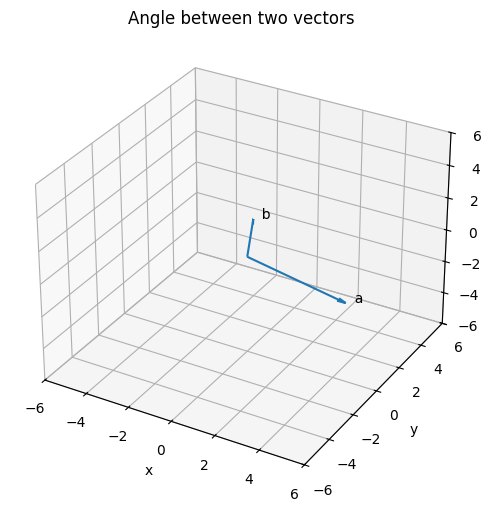

In [81]:
a=sp.Matrix([4,1,-2]); b=sp.Matrix([2,-3,5])
cos_theta=sp.simplify(a.dot(b)/(sp.sqrt(a.dot(a))*sp.sqrt(b.dot(b))))
theta=sp.acos(cos_theta)
show_exact(cos_theta,r'\cos\theta')
print('Angle in degrees:',float(sp.N(theta*180/sp.pi,6)))
plot_vectors_3d([a,b],['a','b'],'Angle between two vectors')

### Classroom Check: What does the sign tell us?

Without computing the angle numerically, what can a positive, zero, or negative dot product tell us about the angle between two nonzero vectors?

In [82]:
reveal_answer_key("concept-5.1-sign", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

> **Orthogonality**
>
> Two vectors $\mathbf u$ and $\mathbf v$ are **orthogonal** when
>
> $$
> \boxed{\mathbf u\cdot\mathbf v=0}.
> $$
>
> For nonzero vectors, this is equivalent to saying the angle between them is $90^\circ$.

## Badminton movement example

Consider two idealized movement vectors on a badminton court:

$$\mathbf{p}=(3,4,-1),\mathbf{q}=(4,-3,0).
$$

Because

$$
\mathbf{p}\cdot\mathbf{q}=3(4)+4(-3)+(-1)(0)=0,
$$

the vectors are orthogonal.

## Three central inequalities and identities

For vectors $\mathbf u$ and $\mathbf v$:

**Cauchy--Schwarz inequality**

$$
|\mathbf u\cdot\mathbf v|\le \|\mathbf u\|\|\mathbf v\|.
$$

**Triangle inequality**

$$
\|\mathbf u+\mathbf v\|\le \|\mathbf u\|+\|\mathbf v\|.
$$

**Pythagorean theorem for orthogonal vectors**

If $\mathbf u\perp\mathbf v$, then

$$
\|\mathbf u+\mathbf v\|^2=\|\mathbf u\|^2+\|\mathbf v\|^2.
$$

The Pythagorean identity follows from expanding the square of the norm:

$$
\|\mathbf u+\mathbf v\|^2
=(\mathbf u+\mathbf v)\cdot(\mathbf u+\mathbf v)
=\|\mathbf u\|^2+2\mathbf u\cdot\mathbf v+\|\mathbf v\|^2.
$$

In [83]:
p=sp.Matrix([3,4,-1]); q=sp.Matrix([4,-3,0])
left=sp.simplify((p+q).dot(p+q))
right=sp.simplify(p.dot(p)+q.dot(q))
print('p dot q =',p.dot(q))
print('||p+q||^2 =',left,'and ||p||^2+||q||^2 =',right)

p dot q = 0
||p+q||^2 = 51 and ||p||^2+||q||^2 = 51


### Classroom Check: Where does the Pythagorean theorem come from?

Which term disappears when the two vectors are orthogonal?

In [84]:
reveal_answer_key("concept-5.1-pythag", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

### Classroom Check: Why is the angle formula always valid?

What does Cauchy--Schwarz guarantee about the ratio used for $\cos\theta$?

In [85]:
reveal_answer_key("concept-5.1-cs", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Matrix form of the dot product

Treat vectors as columns. Then

$$
\boxed{\mathbf u\cdot\mathbf v=\mathbf u^T\mathbf v}.
$$

For example,

$$
\begin{bmatrix}4&1&-2\end{bmatrix}
\begin{bmatrix}2\\-3\\5\end{bmatrix}
=-5.
$$

This connects the dot product directly to matrix multiplication: a row vector times a column vector produces one scalar.

### Classroom Check: Dimension check

If $\mathbf u$ and $\mathbf v$ are $n\times1$ column vectors, why is $\mathbf u^T\mathbf v$ a scalar?

In [86]:
reveal_answer_key("concept-5.1-matrixdot", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

> **Section 5.1 Key Idea**
>
> The dot product connects algebra and geometry: it determines length, distance, angle, directional alignment, and orthogonality.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Norm or length | $\|\mathbf{v}\|=\sqrt{\mathbf{v}\cdot\mathbf{v}}$. |
| Unit vector | Vector of length $1$. |
| Distance | $\|\mathbf{u}-\mathbf{v}\|$. |
| Dot product | Sum of componentwise products. |
| Orthogonal | Dot product equals zero. |
| Angle | Determined by the normalized dot product. |
| Cauchy-Schwarz inequality | $|\mathbf{u}\cdot\mathbf{v}|\le\|\mathbf{u}\|\|\mathbf{v}\|$. |
| Triangle inequality | $\|\mathbf{u}+\mathbf{v}\|\le\|\mathbf{u}\|+\|\mathbf{v}\|$. |

## Section 5.1 worksheet

Work each problem before revealing the solution.

### Problem 1

Find the norm and a unit vector in the direction of $(6,-3,6)$.

In [87]:
reveal_answer_key("5.1-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Find the distance between $(1,4,-2)$ and $(5,-2,1)$.

In [88]:
reveal_answer_key("5.1-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Compute the dot product and angle between $(1,2,2)$ and $(2,0,-1)$.

In [89]:
reveal_answer_key("5.1-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Determine whether $(2,-1,4)$ and $(1,6,1)$ are orthogonal.

In [90]:
reveal_answer_key("5.1-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Verify Cauchy--Schwarz for $(2,1)$ and $(-1,3)$.

In [91]:
reveal_answer_key("5.1-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Write the dot product of $(a,b,c)$ and $(x,y,z)$ as a matrix product.

In [92]:
reveal_answer_key("5.1-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Section 5.2 - Inner Product Spaces

## Learning objectives

Students should be able to:

- verify the inner-product axioms on real vector spaces;
- compute inner products in vector, matrix, polynomial, and function spaces;
- use the induced norm, distance, angle, and orthogonality;
- compute orthogonal projections with a general inner product;
- explain why projection gives the closest point in a one-dimensional subspace.

> **Definition: inner product on a real vector space**
>
> An inner product assigns a real number $\langle\mathbf u,\mathbf v\rangle$ to each pair of vectors and satisfies symmetry, additivity, homogeneity, and positive definiteness.
>
> A vector space equipped with a specified inner product is called an **inner product space**.
>
> In this chapter we work over $\mathbb R$. Complex inner products require conjugate symmetry and will be treated separately later.

## The four real inner-product axioms

For all $\mathbf u,\mathbf v,\mathbf w$ and every real scalar $c$:

1. **Symmetry**

$$
\langle\mathbf u,\mathbf v\rangle=\langle\mathbf v,\mathbf u\rangle.
$$

2. **Additivity**

$$
\langle\mathbf u+\mathbf v,\mathbf w\rangle
=\langle\mathbf u,\mathbf w\rangle+\langle\mathbf v,\mathbf w\rangle.
$$

3. **Homogeneity**

$$
\langle c\mathbf u,\mathbf v\rangle=c\langle\mathbf u,\mathbf v\rangle.
$$

4. **Positive definiteness**

$$
\langle\mathbf v,\mathbf v\rangle\ge0,
$$

with equality if and only if $\mathbf v=\mathbf0$.

These axioms allow us to define

$$
\|\mathbf v\|=\sqrt{\langle\mathbf v,\mathbf v\rangle}
$$

and then build distance, angle, orthogonality, and projection in spaces that may not look like ordinary coordinate space.

### Classroom Check: Why specify “real” here?

Why is the real inner-product definition not copied unchanged into complex vector spaces?

In [93]:
reveal_answer_key("concept-5.2-real", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Weighted R&B feature inner product

Suppose a fictional song feature vector is $(r,b)$, where the components represent two normalized audio features. Define

$$
\langle\mathbf u,\mathbf v\rangle_W
=2u_1v_1+5u_2v_2.
$$

The weights $2$ and $5$ are positive, so

$$
\langle\mathbf v,\mathbf v\rangle_W=2v_1^2+5v_2^2
$$

is nonnegative and equals zero only for $\mathbf v=\mathbf0$.

For

$$
\mathbf u=(3,-1)
$$

and

$$
\mathbf v=(2,4),
$$

we obtain

$$
\langle\mathbf u,\mathbf v\rangle_W=2(3)(2)+5(-1)(4)=-8.
$$

The induced norm of $\mathbf u$ is

$$
\|\mathbf u\|_W=\sqrt{2(3)^2+5(-1)^2}=\sqrt{23}.
$$

> **A form that fails**
>
> The expression
>
> $$
> u_1v_1-u_2v_2
> $$
>
> is not an inner product on $\mathbb R^2$. For the nonzero vector $(0,1)$,
>
> $$
> \langle(0,1),(0,1)\rangle=-1<0,
> $$
>
> so positive definiteness fails.

### Classroom Check: Why do positive weights matter?

What goes wrong if a weighted dot product uses a negative weight?

In [94]:
reveal_answer_key("concept-5.2-weight", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Inner product on polynomial coefficient vectors

For

$$
p(x)=a_0+a_1x+a_2x^2,q(x)=b_0+b_1x+b_2x^2,
$$

define

$$
\langle p,q\rangle
=a_0b_0+2a_1b_1+3a_2b_2.
$$

Let

$$
p(x)=1+2x-x^2,q(x)=3-x+2x^2.
$$

Then

$$
\langle p,q\rangle
=1(3)+2(2)(-1)+3(-1)(2)
=-7.
$$

In [95]:
x=sp.symbols('x')
p=1+2*x-x**2; q=3-x+2*x**2
cp=sp.Matrix([1,2,-1]); cq=sp.Matrix([3,-1,2])
W=sp.diag(1,2,3)
print('Weighted coefficient inner product:',(cp.T*W*cq)[0])

Weighted coefficient inner product: -7


## Integral inner product on functions

On $C[a,b]$, a common inner product is

$$
\boxed{\langle f,g\rangle=\int_a^b f(x)g(x)\,dx}.
$$

For $f(x)=1$ and $g(x)=x$ on $[0,1]$,

$$
\langle f,g\rangle=\int_0^1x\,dx=\frac12.
$$

The “vectors” here are functions, but the inner product still produces a scalar and allows us to discuss length and orthogonality.

> **Projection formula in an inner product space**
>
> For $\mathbf v\ne\mathbf0$,
>
> $$
> \boxed{
> \operatorname{proj}_{\mathbf v}\mathbf u
> =
> \frac{\langle\mathbf u,\mathbf v\rangle}{\langle\mathbf v,\mathbf v\rangle}\mathbf v
> }.
> $$
>
> The residual $\mathbf u-\operatorname{proj}_{\mathbf v}\mathbf u$ is orthogonal to $\mathbf v$.

## Orthogonal projection in $\mathbb{R}^3$

Let

$$
\mathbf{u}=(6,3,3),\mathbf{v}=(1,2,2).
$$

Since

$$
\mathbf{u}\cdot\mathbf{v}=18,\mathbf{v}\cdot\mathbf{v}=9,
$$

we have

$$
\operatorname{proj}_{\mathbf{v}}\mathbf{u}
=\frac{18}{9}\mathbf{v}
=2(1,2,2)
=(2,4,4).
$$

The orthogonal residual is

$$
\mathbf{u}-\operatorname{proj}_{\mathbf{v}}\mathbf{u}
=(4,-1,-1),
$$

and

$$
(4,-1,-1)\cdot(1,2,2)=0.
$$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Residual dot v = 0


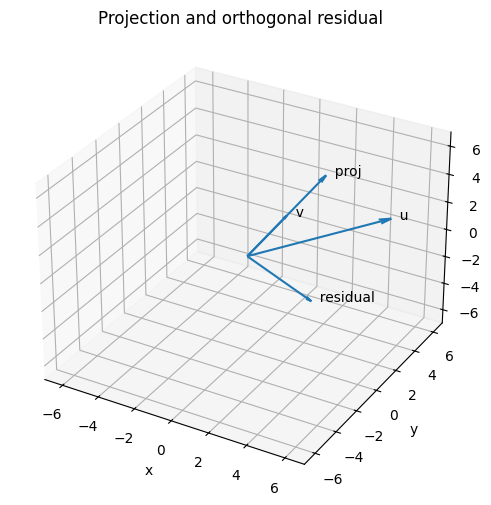

In [96]:
u=sp.Matrix([6,3,3]); v=sp.Matrix([1,2,2])
proj=projection(u,v); residual=u-proj
show_vector(proj,r'\operatorname{proj}_{\mathbf{v}}\mathbf{u}')
show_vector(residual,r'\mathbf{u}-\operatorname{proj}_{\mathbf{v}}\mathbf{u}')
print('Residual dot v =',residual.dot(v))
plot_vectors_3d([u,v,proj,residual],['u','v','proj','residual'],'Projection and orthogonal residual')

### Classroom Check: Why is the residual orthogonal?

Starting from the projection formula, explain why the residual has inner product zero with the projection direction.

In [97]:
reveal_answer_key("concept-5.2-projres", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Why projection minimizes distance

Every vector of the form $c\mathbf v$ lies on the line $\operatorname{span}\{\mathbf v\}$. The projection is the unique point on that line closest to $\mathbf u$.

The reason is geometric: the residual from $\mathbf u$ to its projection is perpendicular to the line. Any other point on the line adds an additional along-the-line displacement, producing a right triangle and therefore a larger distance.

### Classroom Check: Closest-point property

How does the Pythagorean theorem show that the projection is the unique closest point on the line?

In [98]:
reveal_answer_key("concept-5.2-closest", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

> **Section 5.2 Key Idea**
>
> An inner product equips an abstract real vector space with geometry: length, angle, orthogonality, and projection.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Inner product | Scalar-valued function satisfying symmetry, linearity, and positive definiteness. |
| Inner product space | Vector space with a specified inner product. |
| Induced norm | $\|\mathbf{v}\|=\sqrt{\langle\mathbf{v},\mathbf{v}\rangle}$. |
| Orthogonal | Inner product equals zero. |
| Weighted inner product | Coordinates contribute with positive weights. |
| Function inner product | Often an integral of a product. |
| Orthogonal projection | Closest vector in a one-dimensional subspace. |
| Residual | Difference between a vector and its projection. |

## Section 5.2 worksheet

Work each problem before revealing the solution.

### Problem 1

For $\langle\mathbf u,\mathbf v\rangle=3u_1v_1+2u_2v_2$, find $\langle(2,-1),(4,3)\rangle$ and the induced norm of $(2,-1)$.

In [99]:
reveal_answer_key("5.2-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Explain why $u_1v_1+u_2v_2-u_3v_3$ is not an inner product on $\mathbb R^3$.

In [100]:
reveal_answer_key("5.2-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

For $p=a_0+a_1x+a_2x^2$ and $q=b_0+b_1x+b_2x^2$, use $\langle p,q\rangle=a_0b_0+2a_1b_1+3a_2b_2$ to find $\langle1+x+2x^2,2-3x+x^2\rangle$.

In [101]:
reveal_answer_key("5.2-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

On $C[0,1]$, compute $\langle1,x^2\rangle=\int_0^1x^2\,dx$.

In [102]:
reveal_answer_key("5.2-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Find the projection of $(5,1,4)$ onto $(1,0,2)$.

In [103]:
reveal_answer_key("5.2-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Verify that the residual in Problem 5 is orthogonal to the projection direction.

In [104]:
reveal_answer_key("5.2-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Section 5.3 - Orthonormal Bases and the Gram-Schmidt Process

## Learning objectives

Students should be able to:

- distinguish orthogonal and orthonormal sets;
- prove that an orthogonal nonzero set is linearly independent;
- find coordinates relative to an orthonormal basis;
- apply the Gram-Schmidt orthonormalization process;
- construct an orthonormal basis for a solution space.

> **Orthogonal and orthonormal sets**
>
> A set of nonzero vectors is **orthogonal** when every pair of distinct vectors has inner product zero.
>
> It is **orthonormal** when it is orthogonal and every vector has norm $1$.
>
> Thus
>
> $$
> \text{orthonormal} = \text{orthogonal} + \text{unit length}.
> $$

## Why an orthogonal nonzero set is linearly independent

Suppose

$$
\{\mathbf v_1,\ldots,\mathbf v_k\}
$$

is an orthogonal set of nonzero vectors and

$$
c_1\mathbf v_1+\cdots+c_k\mathbf v_k=\mathbf0.
$$

Take the inner product of both sides with $\mathbf v_j$. Because the vectors are mutually orthogonal, every cross term disappears:

$$
c_j\langle\mathbf v_j,\mathbf v_j\rangle=0.
$$

Since $\mathbf v_j\ne\mathbf0$,

$$
\langle\mathbf v_j,\mathbf v_j\rangle>0,
$$

so $c_j=0$. This works for every $j$, hence all coefficients are zero.

Therefore,

$$
\boxed{\text{every orthogonal set of nonzero vectors is linearly independent}.}
$$

### Classroom Check: Which axiom finishes the proof?

Why can we conclude $c_j=0$ from $c_j\langle\mathbf v_j,\mathbf v_j\rangle=0$?

In [105]:
reveal_answer_key("concept-5.3-independent", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## A nonstandard orthonormal basis for $\mathbb{R}^3$

Consider

$$
\mathbf{u}_1=\frac1{\sqrt2}(1,1,0),\mathbf{u}_2=\frac1{\sqrt2}(1,-1,0),
\mathbf{u}_3=(0,0,1).
$$

The pairwise dot products are zero, and each vector has norm one. Therefore the set is an orthonormal basis of $\mathbb{R}^3$.

## Coordinates relative to an orthonormal basis

If

$$
B=\{\mathbf u_1,\ldots,\mathbf u_n\}
$$

is an orthonormal basis and

$$
\mathbf w=c_1\mathbf u_1+\cdots+c_n\mathbf u_n,
$$

then the coefficients are especially simple:

$$
\boxed{c_i=\langle\mathbf w,\mathbf u_i\rangle}.
$$

For

$$
\mathbf w=(9,12,20),
$$

using the orthonormal basis from the previous example gives

$$
c_1=\frac{21}{\sqrt2},
$$

$$
c_2=-\frac3{\sqrt2},
$$

and

$$
c_3=20.
$$

Therefore,

$$
[\mathbf w]_B=
\begin{bmatrix}
21/\sqrt2\\
-3/\sqrt2\\
20
\end{bmatrix}.
$$

In [106]:
s2=sp.sqrt(2)
U=[sp.Matrix([1/s2,1/s2,0]),sp.Matrix([1/s2,-1/s2,0]),sp.Matrix([0,0,1])]
w=sp.Matrix([9,12,20])
coords=sp.Matrix([sp.simplify(w.dot(ui)) for ui in U])
show_vector(coords,r'[\mathbf{w}]_B')
print('Reconstruction check:',sp.simplify(sum((coords[i]*U[i] for i in range(3)),sp.zeros(3,1))-w))

<IPython.core.display.Math object>

Reconstruction check: Matrix([[0], [0], [0]])


### Classroom Check: Why are orthonormal coordinates so easy?

Why does taking an inner product with $\mathbf u_j$ isolate only the $j$th coefficient?

In [107]:
reveal_answer_key("concept-5.3-coordinates", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

> **Gram--Schmidt idea**
>
> Start with linearly independent vectors $\mathbf v_1,\ldots,\mathbf v_k$. Build new vectors by subtracting from each $\mathbf v_j$ its projections onto the directions already constructed.
>
> $$
> \mathbf w_1=\mathbf v_1,
> $$
>
> $$
> \mathbf w_2=\mathbf v_2-\operatorname{proj}_{\mathbf w_1}\mathbf v_2,
> $$
>
> and, in general,
>
> $$
> \boxed{
> \mathbf w_j
> =
> \mathbf v_j-
> \sum_{i=1}^{j-1}
> \operatorname{proj}_{\mathbf w_i}\mathbf v_j
> }.
> $$
>
> The vectors $\mathbf w_i$ are orthogonal. Normalize them at the end to obtain an orthonormal basis.

### Classroom Check: Why subtract projections?

What component is being removed at each Gram--Schmidt step?

In [108]:
reveal_answer_key("concept-5.3-gs", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Detailed Gram-Schmidt example in $\mathbb{R}^3$

Start with

$$
\mathbf{v}_1=(1,1,0),\mathbf{v}_2=(1,0,1),\mathbf{v}_3=(0,1,1).
$$

First,

$$
\mathbf{w}_1=\mathbf{v}_1=(1,1,0).
$$

For the second vector,

$$
\operatorname{proj}_{\mathbf{w}_1}\mathbf{v}_2
=\frac{\mathbf{v}_2\cdot\mathbf{w}_1}{\mathbf{w}_1\cdot\mathbf{w}_1}\mathbf{w}_1
=\frac12(1,1,0),
$$

so

$$
\mathbf{w}_2
=\mathbf{v}_2-\operatorname{proj}_{\mathbf{w}_1}\mathbf{v}_2
=\left(\frac12,-\frac12,1\right).
$$

Scaling does not change orthogonality, so use the simpler vector

$$
\mathbf{w}_2=(1,-1,2).
$$

For the third vector,

$$
\operatorname{proj}_{\mathbf{w}_1}\mathbf{v}_3
=\frac12(1,1,0),
$$

and

$$
\operatorname{proj}_{\mathbf{w}_2}\mathbf{v}_3
=\frac16(1,-1,2).
$$

Therefore

$$
\mathbf{v}_3
-\operatorname{proj}_{\mathbf{w}_1}\mathbf{v}_3
-\operatorname{proj}_{\mathbf{w}_2}\mathbf{v}_3
=\frac23(-1,1,1).
$$

Use

$$
\mathbf{w}_3=(-1,1,1).
$$

After normalization,

$$
\boxed{
\mathbf{u}_1=\frac1{\sqrt2}(1,1,0),\mathbf{u}_2=\frac1{\sqrt6}(1,-1,2),\mathbf{u}_3=\frac1{\sqrt3}(-1,1,1)
}.
$$

**Construct $\mathbf{w}_1$**

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Construct $\mathbf{w}_2$**

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Orthonormality matrix:


⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎣0  0  1⎦

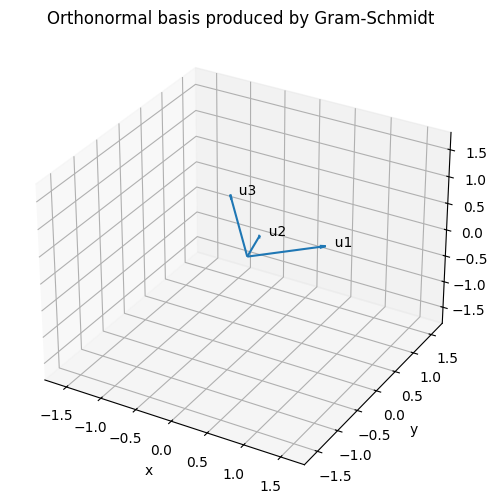

In [109]:
V=[sp.Matrix([1,1,0]),sp.Matrix([1,0,1]),sp.Matrix([0,1,1])]
Ws,Us=gram_schmidt_detailed(V)
print('Orthonormality matrix:')
G=sp.Matrix([[sp.simplify(ui.dot(uj)) for uj in Us] for ui in Us])
display(G)
plot_vectors_3d(Us,['u1','u2','u3'],'Orthonormal basis produced by Gram-Schmidt')

### Classroom Check: Why may we clear fractions?

Why does replacing an orthogonal vector by a nonzero scalar multiple preserve orthogonality?

In [110]:
reveal_answer_key("concept-5.3-scale", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

### Classroom Check: Does Gram--Schmidt change the span?

Why do the original vectors and the new orthogonal vectors generate the same subspace?

In [111]:
reveal_answer_key("concept-5.3-span", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Gram-Schmidt on a solution space

Consider

$$
-x_1+x_2+x_3=0,x_1+x_4=0.
$$

Solving gives a basis

$$
\mathbf{v}_1=(1,1,0,-1),\mathbf{v}_2=(1,0,1,-1).
$$

Normalize the first vector:

$$
\mathbf{u}_1=\frac1{\sqrt3}(1,1,0,-1).
$$

Remove the component of $\mathbf{v}_2$ in the direction of $\mathbf{v}_1$:

$$
\mathbf{w}_2
=\mathbf{v}_2-\frac{\mathbf{v}_2\cdot\mathbf{v}_1}{\mathbf{v}_1\cdot\mathbf{v}_1}\mathbf{v}_1
=\mathbf{v}_2-\frac23\mathbf{v}_1
=\frac13(1,-2,3,-1).
$$

Use the scaled vector $(1,-2,3,-1)$ and normalize:

$$
\mathbf{u}_2=\frac1{\sqrt{15}}(1,-2,3,-1).
$$

Thus an orthonormal basis for the solution space is

$$
\left\{
\frac1{\sqrt3}(1,1,0,-1),
\frac1{\sqrt{15}}(1,-2,3,-1)
\right\}.
$$

In [112]:
A=sp.Matrix([[-1,1,1,0],[1,0,0,1]])
print('Nullspace basis:')
for z in A.nullspace(): display(z)
U1=sp.Matrix([1,1,0,-1])/sp.sqrt(3)
U2=sp.Matrix([1,-2,3,-1])/sp.sqrt(15)
print('A*u1 =',A*U1,'A*u2 =',A*U2,'u1 dot u2 =',sp.simplify(U1.dot(U2)))

Nullspace basis:


⎡0 ⎤
⎢  ⎥
⎢-1⎥
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎣0 ⎦

⎡-1⎤
⎢  ⎥
⎢-1⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣1 ⎦

A*u1 = Matrix([[0], [0]]) A*u2 = Matrix([[0], [0]]) u1 dot u2 = 0


> **Section 5.3 Key Idea**
>
> Orthonormal bases combine two advantages: they are bases, so they represent every vector uniquely, and their orthogonality makes coordinate extraction and projection especially simple.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Orthogonal set | Distinct vectors have inner product zero. |
| Orthonormal set | Orthogonal set of unit vectors. |
| Orthogonal basis | Basis whose vectors are mutually orthogonal. |
| Gram-Schmidt process | Converts a basis into an orthogonal or orthonormal basis. |
| Normalization | Divide a nonzero vector by its norm. |
| Projection subtraction | Removes components along earlier basis vectors. |

## Section 5.3 worksheet

Work each problem before revealing the solution.

### Problem 1

Determine whether $\{(1,1,0),(1,-1,0),(0,0,2)\}$ is orthogonal. Is it orthonormal?

In [113]:
reveal_answer_key("5.3-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Normalize the set in Problem 1.

In [114]:
reveal_answer_key("5.3-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Find the coordinates of $(4,2,3)$ relative to the normalized basis from Problem 2.

In [115]:
reveal_answer_key("5.3-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Apply Gram--Schmidt to $(1,0)$ and $(1,2)$.

In [116]:
reveal_answer_key("5.3-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Apply Gram--Schmidt to $(1,1,0)$ and $(1,0,1)$.

In [117]:
reveal_answer_key("5.3-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Find an orthonormal basis for $\operatorname{span}\{(1,1,1),(1,-1,0)\}$.

In [118]:
reveal_answer_key("5.3-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Section 5.4 - Mathematical Models and Least Squares Analysis

## Learning objectives

Students should be able to:

- formulate a least-squares problem;
- find orthogonal complements and direct sums;
- project onto a subspace;
- identify the four fundamental subspaces;
- solve normal equations;
- construct linear and quadratic least-squares models.

> **Least-squares problem**
>
> Given $A\in\mathbb R^{m\times n}$ and $\mathbf b\in\mathbb R^m$, find $\widehat{\mathbf x}$ minimizing
>
> $$
> \boxed{\|\mathbf b-A\mathbf x\|}.
> $$
>
> The vector $A\widehat{\mathbf x}$ lies in $\operatorname{Col}(A)$ and is the point in that column space closest to $\mathbf b$.

> **Orthogonal complement**
>
> For a subspace $S\subseteq\mathbb R^n$,
>
> $$
> \boxed{
> S^\perp=\{\mathbf x\in\mathbb R^n:\mathbf x\cdot\mathbf s=0\text{ for every }\mathbf s\in S\}
> }.
> $$
>
> The orthogonal complement is itself a subspace.

## Orthogonal Complement Example

Let

$$
S=\operatorname{span}\{(1,1,0,1),(1,0,1,1)\}.
$$

A vector

$$
\mathbf x=
\begin{bmatrix}
x_1\\
x_2\\
x_3\\
x_4
\end{bmatrix}
$$

belongs to $S^\perp$ if it is orthogonal to every vector that spans $S$.

Therefore,

$$
(1,1,0,1)\cdot\mathbf x=0
$$

and

$$
(1,0,1,1)\cdot\mathbf x=0.
$$

These equations can be written as

$$
\begin{bmatrix}
1&1&0&1\\
1&0&1&1
\end{bmatrix}
\begin{bmatrix}
x_1\\
x_2\\
x_3\\
x_4
\end{bmatrix}
=
\begin{bmatrix}
0\\
0
\end{bmatrix}.
$$

Thus, finding $S^\perp$ is equivalent to finding the nullspace of

$$
A=
\begin{bmatrix}
1&1&0&1\\
1&0&1&1
\end{bmatrix}.
$$

The corresponding system is

$$
x_1+x_2+x_4=0,
$$

$$
x_1+x_3+x_4=0.
$$

Subtracting the second equation from the first gives

$$
x_2=x_3.
$$

Let the free variables be

$$
x_2=s,
\qquad
x_4=t.
$$

Then

$$
x_3=s
$$

and

$$
x_1=-s-t.
$$

Therefore,

$$
\mathbf x=
\begin{bmatrix}
-s-t\\
s\\
s\\
t
\end{bmatrix}.
$$

Separate the free parameters:

$$
\mathbf x
=
s
\begin{bmatrix}
-1\\
1\\
1\\
0
\end{bmatrix}
+
t
\begin{bmatrix}
-1\\
0\\
0\\
1
\end{bmatrix}.
$$

Hence,

$$
S^\perp
=
N(A)
=
\operatorname{span}
\left\{
\begin{bmatrix}
-1\\
1\\
1\\
0
\end{bmatrix},
\begin{bmatrix}
-1\\
0\\
0\\
1
\end{bmatrix}
\right\}.
$$

Therefore, a basis for $S^\perp$ is

$$
\boxed{
\left\{
(-1,1,1,0),
(-1,0,0,1)
\right\}.
}
$$

In [119]:
Smat=sp.Matrix([[1,1,0,1],[1,0,1,1]])
for i,z in enumerate(Smat.nullspace(),1): show_vector(z,rf'\mathbf{{z}}_{i}')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Classroom Check: Why does a nullspace appear?

If the spanning vectors of $S$ are written as rows of a matrix, why is $S^\perp$ the nullspace of that matrix?

In [120]:
reveal_answer_key("concept-5.4-perpnull", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Orthogonal decomposition and direct sums

For every subspace $S\subseteq\mathbb R^n$, every vector $\mathbf v\in\mathbb R^n$ can be decomposed uniquely as

$$
\boxed{\mathbf v=\mathbf p+\mathbf r},
$$

where

$$
\mathbf p\in S
$$

and

$$
\mathbf r\in S^\perp.
$$

The vector $\mathbf p$ is the orthogonal projection of $\mathbf v$ onto $S$, and

$$
\mathbf r=\mathbf v-\mathbf p
$$

is the orthogonal residual.

This decomposition is written

$$
\boxed{\mathbb R^n=S\oplus S^\perp}.
$$

The symbol $\oplus$ indicates a **direct sum**: the two components are uniquely determined, and

$$
S\cap S^\perp=\{\mathbf0\}.
$$

### Classroom Check: What does the direct sum mean geometrically?

How would you interpret $\mathbf v=\mathbf p+\mathbf r$ when $S$ is a plane in $\mathbb R^3$?

In [121]:
reveal_answer_key("concept-5.4-directsum", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

> **Projection onto a subspace**
>
> If $\{\mathbf u_1,\ldots,\mathbf u_k\}$ is an orthonormal basis for $S$, then
>
> $$
> \boxed{
> \operatorname{proj}_S\mathbf v
> =
> \sum_{i=1}^k
> \langle\mathbf v,\mathbf u_i\rangle\mathbf u_i
> }.
> $$
>
> If $\{\mathbf w_1,\ldots,\mathbf w_k\}$ is orthogonal but not normalized, then
>
> $$
> \operatorname{proj}_S\mathbf v
> =
> \sum_{i=1}^k
> \frac{\mathbf v\cdot\mathbf w_i}{\mathbf w_i\cdot\mathbf w_i}\mathbf w_i.
> $$

## Projection onto a plane

Let

$$
\mathbf{w}_1=(1,1,0),\mathbf{w}_2=(1,-1,2).
$$

These vectors are orthogonal. Project

$$
\mathbf{v}=(9,12,20)
$$

onto $S=\operatorname{span}\{\mathbf{w}_1,\mathbf{w}_2\}$:

$$
\operatorname{proj}_S\mathbf{v}
=\frac{21}{2}\mathbf{w}_1+\frac{37}{6}\mathbf{w}_2
=\left(\frac{50}{3},\frac{13}{3},\frac{37}{3}\right).
$$

The residual is

$$
\mathbf{v}-\operatorname{proj}_S\mathbf{v}
=\frac{23}{3}(-1,1,1),
$$

which is orthogonal to both spanning vectors.

In [122]:
v=sp.Matrix([9,12,20]); w1=sp.Matrix([1,1,0]); w2=sp.Matrix([1,-1,2])
projS=sp.simplify(v.dot(w1)/w1.dot(w1)*w1 + v.dot(w2)/w2.dot(w2)*w2)
res=v-projS
show_vector(projS,r'\operatorname{proj}_{S}\mathbf{v}')
show_vector(res,r'\mathbf{r}')
print('r dot w1 =',sp.simplify(res.dot(w1)),'r dot w2 =',sp.simplify(res.dot(w2)))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

r dot w1 = 0 r dot w2 = 0


### Classroom Check: Why is an orthogonal basis convenient for projection?

Why can the projection components be computed one direction at a time?

In [123]:
reveal_answer_key("concept-5.4-proj", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## The Four Fundamental Subspaces

Consider

$$
A=
\begin{bmatrix}
1&2&0&1\\
0&1&1&1\\
1&3&1&2
\end{bmatrix}.
$$

Since $A$ has 3 rows and 4 columns,

$$
A\in\mathbb R^{3\times 4}.
$$

Associated with $A$ are four important subspaces:

1. the **row space** $\operatorname{Row}(A)$;
2. the **column space** $\operatorname{Col}(A)$;
3. the **nullspace** $N(A)$;
4. the **left nullspace** $N(A^T)$.

We will find a basis for each one and explain how they are related.

---

### Step 1: Row-reduce the matrix

Notice first that the third row is the sum of the first two rows:

$$
R_3=R_1+R_2.
$$

Therefore, the rows cannot all be linearly independent.

Row reduction gives

$$
\operatorname{rref}(A)=
\begin{bmatrix}
1&0&-2&-1\\
0&1&1&1\\
0&0&0&0
\end{bmatrix}.
$$

There are two pivot positions, so

$$
\boxed{\operatorname{rank}(A)=2.}
$$

Recall that the rank of a matrix is the dimension of both its row space and its column space:

$$
\boxed{
\operatorname{rank}(A)
=
\dim(\operatorname{Row}(A))
=
\dim(\operatorname{Col}(A)).
}
$$

Therefore,

$$
\dim(\operatorname{Row}(A))=2
$$

and

$$
\dim(\operatorname{Col}(A))=2.
$$

---

## 1. Row Space

The **row space** of $A$ is the span of the rows of $A$:

$$
\operatorname{Row}(A)
=
\operatorname{span}
\left\{
(1,2,0,1),
(0,1,1,1),
(1,3,1,2)
\right\}.
$$

Because

$$
(1,3,1,2)
=
(1,2,0,1)+(0,1,1,1),
$$

the third row does not provide a new independent direction.

A useful fact is that **row operations preserve the row space**. Therefore, the nonzero rows of the RREF form a basis for the row space.

Hence,

$$
\boxed{
\operatorname{Row}(A)
=
\operatorname{span}
\left\{
(1,0,-2,-1),
(0,1,1,1)
\right\}.
}
$$

Thus, one basis for the row space is

$$
\boxed{
\left\{
(1,0,-2,-1),
(0,1,1,1)
\right\}.
}
$$

There are two basis vectors, confirming that

$$
\dim(\operatorname{Row}(A))=2.
$$

Because each row has four components,

$$
\boxed{
\operatorname{Row}(A)\subseteq\mathbb R^4.
}
$$

---

## 2. Column Space

The **column space** of $A$ is the span of its columns.

Write

$$
A=
\begin{bmatrix}
\mathbf a_1&
\mathbf a_2&
\mathbf a_3&
\mathbf a_4
\end{bmatrix}.
$$

The pivot columns of the RREF are columns 1 and 2.

Therefore, columns 1 and 2 of the **original matrix** form a basis for the column space.

The original first two columns are

$$
\mathbf a_1=
\begin{bmatrix}
1\\
0\\
1
\end{bmatrix},
\qquad
\mathbf a_2=
\begin{bmatrix}
2\\
1\\
3
\end{bmatrix}.
$$

Hence,

$$
\boxed{
\operatorname{Col}(A)
=
\operatorname{span}
\left\{
\begin{bmatrix}
1\\
0\\
1
\end{bmatrix},
\begin{bmatrix}
2\\
1\\
3
\end{bmatrix}
\right\}.
}
$$

Therefore, a basis for the column space is

$$
\boxed{
\left\{
\begin{bmatrix}
1\\
0\\
1
\end{bmatrix},
\begin{bmatrix}
2\\
1\\
3
\end{bmatrix}
\right\}.
}
$$

There are two basis vectors, so

$$
\dim(\operatorname{Col}(A))=2.
$$

Because every column of $A$ has three components,

$$
\boxed{
\operatorname{Col}(A)\subseteq\mathbb R^3.
}
$$

> **Important:** We use the pivot positions from the RREF, but we take the basis vectors from the **original matrix**. Row operations generally change the column space, so the pivot columns of the RREF should not be used as a basis for $\operatorname{Col}(A)$.

---

## 3. Nullspace

The **nullspace** of $A$ consists of all vectors $\mathbf x$ satisfying

$$
A\mathbf x=\mathbf 0.
$$

Let

$$
\mathbf x=
\begin{bmatrix}
x_1\\
x_2\\
x_3\\
x_4
\end{bmatrix}.
$$

Using the RREF,

$$
\begin{bmatrix}
1&0&-2&-1\\
0&1&1&1\\
0&0&0&0
\end{bmatrix}
\begin{bmatrix}
x_1\\
x_2\\
x_3\\
x_4
\end{bmatrix}
=
\begin{bmatrix}
0\\
0\\
0
\end{bmatrix}.
$$

This gives

$$
x_1-2x_3-x_4=0
$$

and

$$
x_2+x_3+x_4=0.
$$

The pivot variables are

$$
x_1,\;x_2,
$$

and the free variables are

$$
x_3,\;x_4.
$$

Let

$$
x_3=s,
\qquad
x_4=t.
$$

Then

$$
x_1=2s+t
$$

and

$$
x_2=-s-t.
$$

Therefore,

$$
\mathbf x
=
\begin{bmatrix}
2s+t\\
-s-t\\
s\\
t
\end{bmatrix}.
$$

Separate the parameters:

$$
\mathbf x
=
s
\begin{bmatrix}
2\\
-1\\
1\\
0
\end{bmatrix}
+
t
\begin{bmatrix}
1\\
-1\\
0\\
1
\end{bmatrix}.
$$

Thus,

$$
\boxed{
N(A)
=
\operatorname{span}
\left\{
\begin{bmatrix}
2\\
-1\\
1\\
0
\end{bmatrix},
\begin{bmatrix}
1\\
-1\\
0\\
1
\end{bmatrix}
\right\}.
}
$$

A basis for the nullspace is therefore

$$
\boxed{
\left\{
(2,-1,1,0),
(1,-1,0,1)
\right\}.
}
$$

Because there are two free variables,

$$
\boxed{\dim N(A)=2.}
$$

This also agrees with the Rank-Nullity Theorem:

$$
\operatorname{rank}(A)+\operatorname{nullity}(A)=4.
$$

Since

$$
\operatorname{rank}(A)=2,
$$

we obtain

$$
\operatorname{nullity}(A)=4-2=2.
$$

Because vectors in $N(A)$ have four components,

$$
\boxed{
N(A)\subseteq\mathbb R^4.
}
$$

---

## 4. Left Nullspace

The **left nullspace** of $A$ is defined as

$$
\boxed{N(A^T)}.
$$

It consists of all vectors $\mathbf y$ satisfying

$$
A^T\mathbf y=\mathbf 0.
$$

Equivalently,

$$
\mathbf y^TA=\mathbf 0^T.
$$

This explains the word **left**: the vector $\mathbf y^T$ multiplies $A$ from the left.

For this matrix, we already observed that

$$
R_3=R_1+R_2.
$$

Rearranging,

$$
-R_1-R_2+R_3=\mathbf 0.
$$

The coefficients in this linear relationship are

$$
-1,\;-1,\;1.
$$

Therefore,

$$
\begin{bmatrix}
-1&-1&1
\end{bmatrix}A
=
\mathbf 0^T.
$$

Equivalently,

$$
A^T
\begin{bmatrix}
-1\\
-1\\
1
\end{bmatrix}
=
\mathbf 0.
$$

Hence,

$$
\boxed{
N(A^T)
=
\operatorname{span}
\left\{
\begin{bmatrix}
-1\\
-1\\
1
\end{bmatrix}
\right\}.
}
$$

So a basis for the left nullspace is

$$
\boxed{
\left\{
(-1,-1,1)
\right\}.
}
$$

Because $A^T$ has three columns and

$$
\operatorname{rank}(A^T)=\operatorname{rank}(A)=2,
$$

the Rank-Nullity Theorem gives

$$
\dim N(A^T)=3-2=1.
$$

Because vectors in $N(A^T)$ have three components,

$$
\boxed{
N(A^T)\subseteq\mathbb R^3.
}
$$

---

# The Two Ambient Spaces

The four fundamental subspaces naturally occur in two different spaces.

Because $A$ has four columns,

$$
\boxed{
\operatorname{Row}(A),N(A)\subseteq\mathbb R^4.
}
$$

Because $A$ has three rows,

$$
\boxed{
\operatorname{Col}(A),N(A^T)\subseteq\mathbb R^3.
}
$$

So the spaces are paired as

$$
\mathbb R^4:
\qquad
\operatorname{Row}(A)
\text{ and }
N(A),
$$

and

$$
\mathbb R^3:
\qquad
\operatorname{Col}(A)
\text{ and }
N(A^T).
$$

---

# Why Are the Spaces Orthogonal?

Suppose

$$
\mathbf x\in N(A).
$$

Then

$$
A\mathbf x=\mathbf 0.
$$

Each entry of $A\mathbf x$ is the dot product of one row of $A$ with $\mathbf x$.

Therefore, $\mathbf x$ is orthogonal to every row of $A$.

Hence,

$$
\boxed{
N(A)=\operatorname{Row}(A)^\perp.
}
$$

Similarly, suppose

$$
\mathbf y\in N(A^T).
$$

Then

$$
A^T\mathbf y=\mathbf 0.
$$

This means $\mathbf y$ is orthogonal to every column of $A$.

Therefore,

$$
\boxed{
N(A^T)=\operatorname{Col}(A)^\perp.
}
$$

---

# Dimension Check

For this $3\times4$ matrix,

| Fundamental subspace | Ambient space | Dimension |
|---|---|---:|
| $\operatorname{Row}(A)$ | $\mathbb R^4$ | $2$ |
| $N(A)$ | $\mathbb R^4$ | $2$ |
| $\operatorname{Col}(A)$ | $\mathbb R^3$ | $2$ |
| $N(A^T)$ | $\mathbb R^3$ | $1$ |

Notice that

$$
2+2=4
$$

and

$$
2+1=3.
$$

This reflects the orthogonal direct-sum decompositions

$$
\boxed{
\mathbb R^4
=
\operatorname{Row}(A)
\oplus
N(A)
}
$$

and

$$
\boxed{
\mathbb R^3
=
\operatorname{Col}(A)
\oplus
N(A^T).
}
$$

Thus, every vector in $\mathbb R^4$ can be written uniquely as

$$
\text{row-space component}
+
\text{nullspace component},
$$

and every vector in $\mathbb R^3$ can be written uniquely as

$$
\text{column-space component}
+
\text{left-nullspace component}.
$$

---

## Summary

For this matrix,

$$
\boxed{\operatorname{rank}(A)=2}
$$

and the four fundamental subspaces are

$$
\boxed{
\operatorname{Row}(A)
=
\operatorname{span}
\{(1,0,-2,-1),(0,1,1,1)\}
}
$$

$$
\boxed{
\operatorname{Col}(A)
=
\operatorname{span}
\left\{
\begin{bmatrix}
1\\
0\\
1
\end{bmatrix},
\begin{bmatrix}
2\\
1\\
3
\end{bmatrix}
\right\}
}
$$

$$
\boxed{
N(A)
=
\operatorname{span}
\{(2,-1,1,0),(1,-1,0,1)\}
}
$$

and

$$
\boxed{
N(A^T)
=
\operatorname{span}
\{(-1,-1,1)\}.
}
$$

The central relationships are

$$
\boxed{
N(A)=\operatorname{Row}(A)^\perp
}
$$

and

$$
\boxed{
N(A^T)=\operatorname{Col}(A)^\perp.
}
$$

In [124]:
A=sp.Matrix([[1,2,0,1],[0,1,1,1],[1,3,1,2]])
R,piv=A.rref()
show_matrix(R,r'\operatorname{rref}(A)')
print('Pivot-column indices (0-based Python):', piv)
print('Mathematical pivot columns (1-based):', tuple(j+1 for j in piv))
print('Nullspace:')
for z in A.nullspace(): display(z)
print('Left nullspace:')
for z in A.T.nullspace(): display(z)

<IPython.core.display.Math object>

Pivot-column indices (0-based Python): (0, 1)
Mathematical pivot columns (1-based): (1, 2)
Nullspace:


⎡2 ⎤
⎢  ⎥
⎢-1⎥
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎣0 ⎦

⎡1 ⎤
⎢  ⎥
⎢-1⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣1 ⎦

Left nullspace:


⎡-1⎤
⎢  ⎥
⎢-1⎥
⎢  ⎥
⎣1 ⎦

### Classroom Check: Why are these spaces orthogonal?

Explain directly from $A\mathbf x=\mathbf0$ why the nullspace is orthogonal to every row of $A$.

In [125]:
reveal_answer_key("concept-5.4-four", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Why the normal equations appear

Let

$$
\mathbf r=\mathbf b-A\widehat{\mathbf x}
$$

be the least-squares residual. The fitted vector $A\widehat{\mathbf x}$ is the closest vector in $\operatorname{Col}(A)$ to $\mathbf b$.

The shortest path from a point to a subspace is perpendicular to that subspace, so

$$
\mathbf r\perp\operatorname{Col}(A).
$$

Because the columns of $A$ span $\operatorname{Col}(A)$, this means

$$
A^T\mathbf r=\mathbf0.
$$

Substitute $\mathbf r=\mathbf b-A\widehat{\mathbf x}$:

$$
A^T(\mathbf b-A\widehat{\mathbf x})=\mathbf0.
$$

Therefore,

$$
\boxed{A^TA\widehat{\mathbf x}=A^T\mathbf b}.
$$

These are the **normal equations**. They are the algebraic expression of the geometric orthogonality condition.

### Classroom Check: What is really being minimized?

Why does $A^T\mathbf r=\mathbf0$ encode perpendicularity to the entire column space rather than just one vector?

In [126]:
reveal_answer_key("concept-5.4-normal", "Reveal explanation")

Let the residual be

$$
\mathbf r=\mathbf b-A\widehat{\mathbf x}.
$$

The fitted vector $A\widehat{\mathbf x}$ is the point in $\operatorname{Col}(A)$ closest to $\mathbf b$. Therefore the shortest error vector is perpendicular to the entire column space. Since the columns of $A$ span that space,

$$
A^T\mathbf r=\mathbf0.
$$

Substituting the residual gives

$$
A^T(\mathbf b-A\widehat{\mathbf x})=\mathbf0,
$$

hence

$$
A^TA\widehat{\mathbf x}=A^T\mathbf b.
$$

### Classroom Check: When is the coefficient vector unique?

What condition on $A^TA$ guarantees a unique least-squares coefficient vector?

In [127]:
reveal_answer_key("concept-5.4-unique", "Reveal explanation")

The normal equations can have more than one coefficient vector if the columns of $A$ contain redundant directions. A unique least-squares coefficient vector is guaranteed when $A^TA$ is invertible. Later formulations express this as requiring the columns of $A$ to be linearly independent.

## Driving-data regression line

A fictional driving dataset uses

$$
(1,2),(2,3),(3,5),(4,4),(5,7).
$$

Fit

$$
y=c_0+c_1x.
$$

The design matrix and data vector are

$$
A=
\begin{bmatrix}
1&1\\
1&2\\
1&3\\
1&4\\
1&5
\end{bmatrix}
$$

and

$$
\mathbf b=
\begin{bmatrix}2\\3\\5\\4\\7\end{bmatrix}.
$$

Compute

$$
A^TA=
\begin{bmatrix}5&15\\15&55\end{bmatrix}
$$

and

$$
A^T\mathbf b=
\begin{bmatrix}21\\75\end{bmatrix}.
$$

The normal equations give

$$
c_0=\frac9{10},
$$

and

$$
c_1=\frac{11}{10}.
$$

Therefore,

$$
\boxed{\widehat y=0.9+1.1x}.
$$

The predicted values are

$$
2.0,3.1,4.2,5.3,6.4,
$$

so the residual vector $\mathbf r=\mathbf b-A\widehat{\mathbf x}$ is

$$
\mathbf r=(0,-0.1,0.8,-1.3,0.6).
$$

Its dot product with each column of $A$ is zero, which verifies the normal-equation geometry.

coefficients: [0.9 1.1]


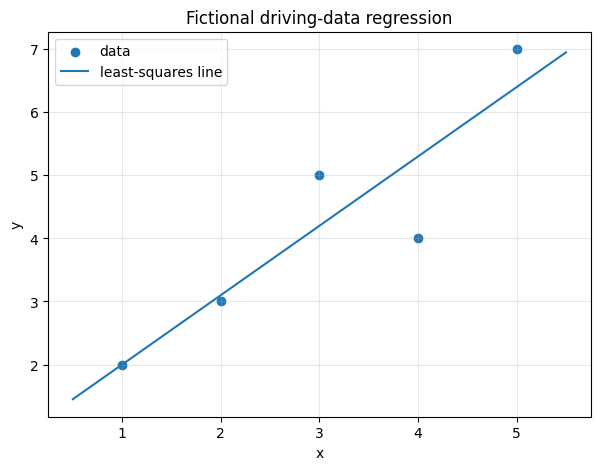

In [128]:
xs=np.array([1,2,3,4,5],dtype=float)
ys=np.array([2,3,5,4,7],dtype=float)
A=np.column_stack([np.ones_like(xs),xs])
coef=np.linalg.solve(A.T@A,A.T@ys)
print('coefficients:',coef)
xx=np.linspace(.5,5.5,200)
plt.figure(figsize=(7,5)); plt.scatter(xs,ys,label='data'); plt.plot(xx,coef[0]+coef[1]*xx,label='least-squares line')
plt.xlabel('x'); plt.ylabel('y'); plt.grid(alpha=.3); plt.legend(); plt.title('Fictional driving-data regression'); plt.show()

## Quadratic travel model

Suppose a fictional travel-planning response is observed at

$$
(0,3),(1,6),(2,11),(3,18),(4,28).
$$

Fit

$$
y=c_0+c_1x+c_2x^2.
$$

Now the design matrix has three columns: one for the constant term, one for $x$, and one for $x^2$.

Solving the quadratic normal equations gives

$$
\boxed{
\widehat y
=\frac{108}{35}+\frac{57}{35}x+\frac87x^2
}.
$$

The residual sum of squares is

$$
\boxed{\frac4{35}}.
$$

The same least-squares geometry applies: the fitted data vector is the orthogonal projection of the observed data vector onto the three-dimensional column space of the quadratic design matrix.

quadratic coefficients: [3.0857 1.6286 1.1429]


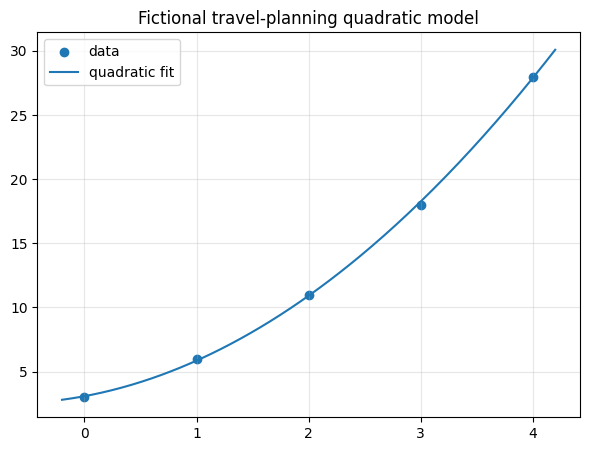

In [129]:
xs2=np.arange(5,dtype=float); ys2=np.array([3,6,11,18,28],dtype=float)
A2=np.column_stack([np.ones_like(xs2),xs2,xs2**2])
c2=np.linalg.solve(A2.T@A2,A2.T@ys2)
print('quadratic coefficients:',c2)
xx=np.linspace(-.2,4.2,200)
plt.figure(figsize=(7,5)); plt.scatter(xs2,ys2,label='data'); plt.plot(xx,c2[0]+c2[1]*xx+c2[2]*xx**2,label='quadratic fit')
plt.grid(alpha=.3); plt.legend(); plt.title('Fictional travel-planning quadratic model'); plt.show()

> **Section 5.4 Key Idea**
>
> Least squares replaces an inconsistent equation by an orthogonal projection problem. The residual belongs to the orthogonal complement of the column space.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Least-squares solution | Minimizes $\|A\mathbf{x}-\mathbf{b}\|$. |
| Orthogonal complement | Vectors orthogonal to every vector in a subspace. |
| Direct sum | Unique decomposition into vectors from two subspaces. |
| Projection onto a subspace | Closest vector in that subspace. |
| Four fundamental subspaces | $\operatorname{Col}(A)$, $N(A)$, $\operatorname{Col}(A^T)$, and $N(A^T)$. |
| Normal equations | $A^TA\widehat{\mathbf{x}}=A^T\mathbf{b}$. |
| Residual | $\mathbf{b}-A\widehat{\mathbf{x}}$. |
| Regression model | Least-squares model for observed data. |

## Section 5.4 worksheet

Work each problem before revealing the solution.

### Problem 1

Find a basis for the orthogonal complement of $\operatorname{span}\{(1,1,0),(0,1,1)\}$.

In [130]:
reveal_answer_key("5.4-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Project $(4,5,6)$ onto the line spanned by $(1,1,1)$.

In [131]:
reveal_answer_key("5.4-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Project $(3,1,4)$ onto the plane spanned by the orthogonal vectors $(1,1,0)$ and $(1,-1,2)$.

In [132]:
reveal_answer_key("5.4-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Find rank, a row-space basis, a column-space basis, and a nullspace basis for $\begin{bmatrix}1&2&3\\2&4&6\\0&1&1\end{bmatrix}$.

In [133]:
reveal_answer_key("5.4-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Find the least-squares line for $(0,1),(1,2),(2,2),(3,5)$.

In [134]:
reveal_answer_key("5.4-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Verify that the residual from Problem 5 is orthogonal to both columns of the design matrix.

In [135]:
reveal_answer_key("5.4-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Section 5.5 - Applications of Inner Product Spaces

## Learning objectives

Students should be able to:

- compute and interpret the cross product in $\mathbb{R}^3$;
- find vectors orthogonal to two given vectors;
- use cross products to find area and angle;
- construct continuous least-squares approximations;
- compute finite Fourier approximations.

> **Definition: cross product**
>
> For $\mathbf u,\mathbf v\in\mathbb R^3$, the cross product $\mathbf u\times\mathbf v$ is perpendicular to both $\mathbf u$ and $\mathbf v$. Its magnitude is
>
> $$
> \boxed{
> \|\mathbf u\times\mathbf v\|
> =\|\mathbf u\|\|\mathbf v\|\sin\theta
> }.
> $$
>
> For
>
> $$
> \mathbf u=(u_1,u_2,u_3)
> $$
>
> and
>
> $$
> \mathbf v=(v_1,v_2,v_3),
> $$
>
> $$
> \mathbf u\times\mathbf v
> =
> \left(
> u_2v_3-u_3v_2,
> u_3v_1-u_1v_3,
> u_1v_2-u_2v_1
> \right).
> $$
>
> The right-hand rule determines its direction, and reversing the order reverses the sign.

## Hiking-trail cross product

Let two trail-direction vectors be

$$
\mathbf u=(4,1,2)
$$

and

$$
\mathbf v=(1,3,-1).
$$

Then

$$
\mathbf u\times\mathbf v=(-7,6,11).
$$

Check orthogonality:

$$
(-7,6,11)\cdot(4,1,2)=0,
$$

and

$$
(-7,6,11)\cdot(1,3,-1)=0.
$$

The parallelogram area is

$$
\|\mathbf u\times\mathbf v\|=\sqrt{206},
$$

so the triangle area is

$$
\frac{\sqrt{206}}2.
$$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

dot checks: 0 0


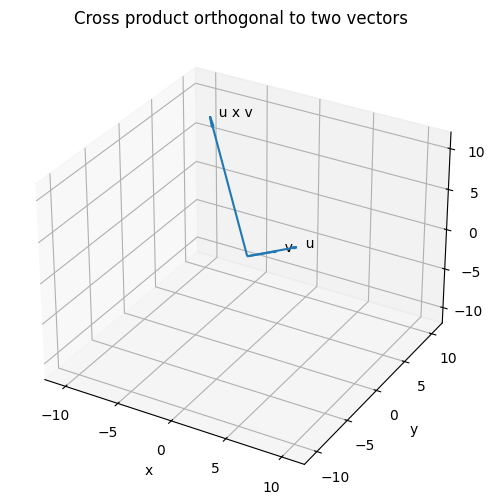

In [136]:
u=sp.Matrix([4,1,2]); v=sp.Matrix([1,3,-1]); cross=u.cross(v)
show_vector(cross,r'\mathbf{u}\times\mathbf{v}')
show_exact(sp.sqrt(cross.dot(cross)),r'\|\mathbf{u}\times\mathbf{v}\|')
print('dot checks:',cross.dot(u),cross.dot(v))
plot_vectors_3d([u,v,cross],['u','v','u x v'],'Cross product orthogonal to two vectors')

### Classroom Check: Why does order matter?

What is the relationship between $\mathbf u\times\mathbf v$ and $\mathbf v\times\mathbf u$?

In [137]:
reveal_answer_key("concept-5.5-order", "Reveal explanation")

The cross product is order-sensitive:

$$
\mathbf v\times\mathbf u=-(\mathbf u\times\mathbf v).
$$

The two vectors have the same magnitude but opposite directions. The right-hand rule determines which of the two normal directions corresponds to $\mathbf u\times\mathbf v$.

### Classroom Check: Why does the cross-product magnitude give area?

Connect $\|\mathbf u\times\mathbf v\|=\|\mathbf u\|\|\mathbf v\|\sin\theta$ with base times height.

In [138]:
reveal_answer_key("concept-5.5-area", "Reveal explanation")

Because

$$
\|\mathbf u\times\mathbf v\|=\|\mathbf u\|\|\mathbf v\|\sin\theta,
$$

its magnitude equals base times perpendicular height, which is the area of the parallelogram determined by $\mathbf u$ and $\mathbf v$. Half of that gives the triangle area.

## Unit normal vectors

A unit vector orthogonal to both $\mathbf{u}$ and $\mathbf{v}$ is

$$
\frac1{\sqrt{206}}(-7,6,11).
$$

Its negative is the other unit normal.

> **Continuous least squares**
>
> For the inner product
>
> $$
> \langle f,g\rangle=\int_a^b f(x)g(x)\,dx,
> $$
>
> a least-squares approximation is an orthogonal projection of $f$ onto a finite-dimensional function subspace.
>
> If $g$ lies in $S=\operatorname{span}\{\phi_1,\ldots,\phi_k\}$, then the best approximation satisfies
>
> $$
> \boxed{\langle f-g,\phi_j\rangle=0}
> $$
>
> for every basis function $\phi_j$.

### Classroom Check: What replaces $A^T\mathbf r=0$ for functions?

How do the orthogonality equations for the error play the role of normal equations?

In [139]:
reveal_answer_key("concept-5.5-continuous", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Best linear approximation to $f(x)=x^2$ on $[0,1]$

Approximate $f(x)=x^2$ by

$$
g(x)=a+bx.
$$

The error must be orthogonal to both basis functions $1$ and $x$:

$$
\langle x^2-a-bx,1\rangle=0,
$$

$$
\langle x^2-a-bx,x\rangle=0.
$$

Therefore,

$$
\begin{aligned}
\int_0^1(x^2-a-bx)\,dx&=0,\\
\int_0^1x(x^2-a-bx)\,dx&=0.
\end{aligned}
$$

This gives

$$
\begin{aligned}
a+\frac12b&=\frac13,\\
\frac12a+\frac13b&=\frac14.
\end{aligned}
$$

Solving,

$$
a=-\frac16,

b=1.
$$

Hence

$$
\boxed{g(x)=x-\frac16}.
$$

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

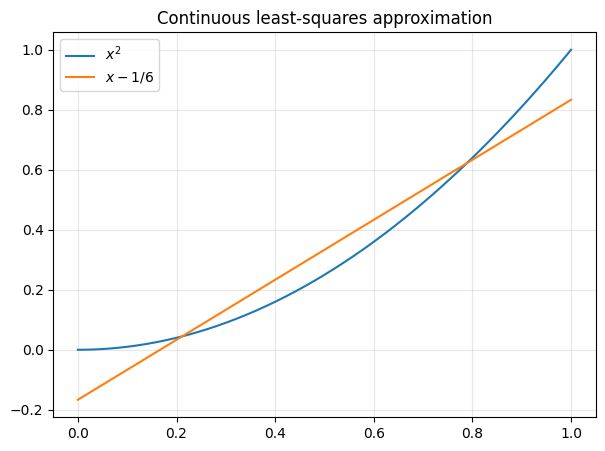

In [140]:
x=sp.symbols('x', real=True)
G=sp.Matrix([[sp.integrate(1,(x,0,1)),sp.integrate(x,(x,0,1))],
             [sp.integrate(x,(x,0,1)),sp.integrate(x**2,(x,0,1))]])
rhs=sp.Matrix([sp.integrate(x**2,(x,0,1)),sp.integrate(x**3,(x,0,1))])
coef=G.LUsolve(rhs)
show_matrix(G,'G'); show_vector(rhs,r'\mathbf{d}'); show_vector(coef,r'\begin{bmatrix}a\\b\end{bmatrix}')
xx=np.linspace(0,1,300)
plt.figure(figsize=(7,5)); plt.plot(xx,xx**2,label='$x^2$'); plt.plot(xx,xx-1/6,label='$x-1/6$')
plt.grid(alpha=.3); plt.legend(); plt.title('Continuous least-squares approximation'); plt.show()

## Fourier approximation as orthogonal projection

On $[0,2\pi]$, consider the centered ramp

$$
f(x)=x-\pi.
$$

Over a full period, the functions

$$
1,\cos x,\sin x,\cos(2x),\sin(2x),\ldots
$$

form an orthogonal family under the integral inner product. Therefore Fourier coefficients are projection coefficients onto trigonometric directions.

For this centered ramp,

$$
a_0=0,
$$

$$
a_n=0,
$$

and

$$
b_n=-\frac2n.
$$

Keeping the first three sine frequencies gives

$$
\boxed{
S_3(x)=-2\sin x-\sin(2x)-\frac23\sin(3x)
}.
$$

As the order increases, the finite trigonometric projection captures more of the function. Near the jump in the periodic extension, visible oscillation may remain even for higher orders.

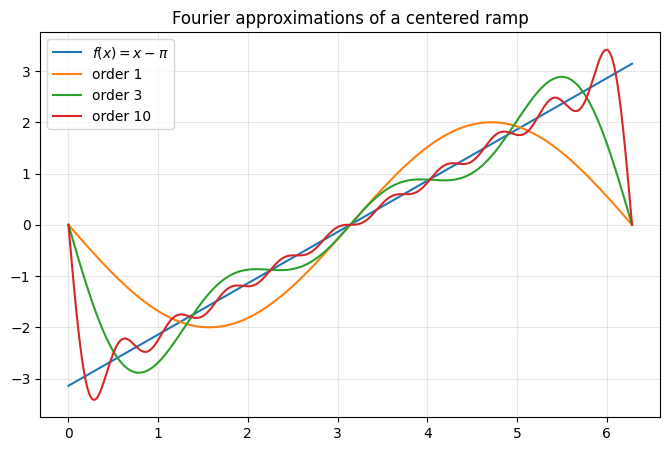

In [141]:
xx=np.linspace(0,2*np.pi,1000)
f=xx-np.pi
S1=-2*np.sin(xx)
S3=-2*np.sin(xx)-np.sin(2*xx)-(2/3)*np.sin(3*xx)
S10=sum((-2/n)*np.sin(n*xx) for n in range(1,11))
plt.figure(figsize=(8,5)); plt.plot(xx,f,label='$f(x)=x-\\pi$'); plt.plot(xx,S1,label='order 1'); plt.plot(xx,S3,label='order 3'); plt.plot(xx,S10,label='order 10')
plt.grid(alpha=.3); plt.legend(); plt.title('Fourier approximations of a centered ramp'); plt.show()

### Classroom Check: Why are Fourier coefficients coordinate-like?

How is extracting a Fourier coefficient analogous to taking coordinates in an orthogonal basis?

In [142]:
reveal_answer_key("concept-5.5-fourier", "Reveal explanation")

ToggleButton(value=False, button_style='info', description='Reveal explanation', icon='eye', layout=Layout(wid…

## Interactive Fourier order

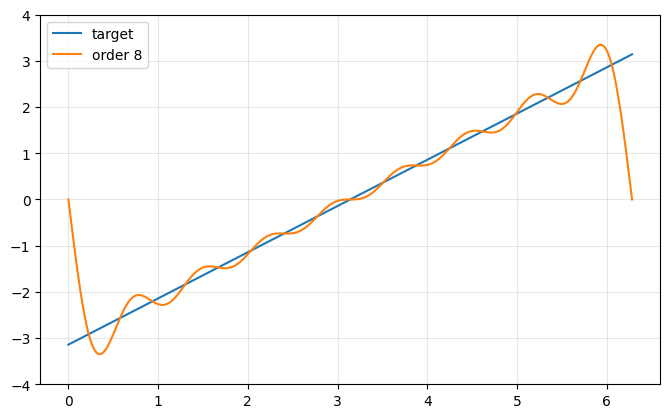

In [143]:
if WIDGETS_AVAILABLE:
    @interact(n=IntSlider(value=3,min=1,max=20,step=1,description='order'))
    def fourier_order(n=3):
        xx=np.linspace(0,2*np.pi,1000)
        f=xx-np.pi
        Sn=sum((-2/k)*np.sin(k*xx) for k in range(1,n+1))
        plt.figure(figsize=(8,4.8)); plt.plot(xx,f,label='target'); plt.plot(xx,Sn,label=f'order {n}')
        plt.grid(alpha=.3); plt.legend(); plt.ylim(-4,4); plt.show()
else:
    print('ipywidgets is unavailable; the static Fourier plots above remain usable.')

> **Section 5.5 Key Idea**
>
> Cross products solve three-dimensional perpendicularity and area problems, while function-space projections turn the same orthogonality principle into continuous least squares and Fourier approximation.

## Definitions and terminology

| Term | Meaning |
|---|---|
| Cross product | Vector orthogonal to two vectors in $\mathbb{R}^3$. |
| Unit normal | Unit vector perpendicular to a plane. |
| Parallelogram area | $\|\mathbf{u}\times\mathbf{v}\|$. |
| Continuous least squares | Projection in a function inner product space. |
| Approximating subspace | Finite-dimensional function space used for approximation. |
| Fourier coefficients | Coordinates relative to trigonometric orthogonal functions. |
| Fourier approximation | Finite trigonometric least-squares approximation. |
| Approximation order | Highest sine or cosine frequency retained. |

## Section 5.5 worksheet

Work each problem before revealing the solution.

### Problem 1

Find $(2,1,-1)\times(1,-2,3)$.

In [144]:
reveal_answer_key("5.5-1", "Reveal Problem 1")

ToggleButton(value=False, button_style='info', description='Reveal Problem 1', icon='eye', layout=Layout(width…

### Problem 2

Verify that the answer to Problem 1 is orthogonal to both original vectors.

In [145]:
reveal_answer_key("5.5-2", "Reveal Problem 2")

ToggleButton(value=False, button_style='info', description='Reveal Problem 2', icon='eye', layout=Layout(width…

### Problem 3

Find the parallelogram and triangle areas determined by the two vectors in Problem 1.

In [146]:
reveal_answer_key("5.5-3", "Reveal Problem 3")

ToggleButton(value=False, button_style='info', description='Reveal Problem 3', icon='eye', layout=Layout(width…

### Problem 4

Find a unit normal to the plane spanned by $(1,0,1)$ and $(0,2,1)$.

In [147]:
reveal_answer_key("5.5-4", "Reveal Problem 4")

ToggleButton(value=False, button_style='info', description='Reveal Problem 4', icon='eye', layout=Layout(width…

### Problem 5

Find the best constant approximation to $f(x)=x$ on $[0,2]$.

In [148]:
reveal_answer_key("5.5-5", "Reveal Problem 5")

ToggleButton(value=False, button_style='info', description='Reveal Problem 5', icon='eye', layout=Layout(width…

### Problem 6

Write the second-order Fourier approximation of $f(x)=x-\pi$ on $[0,2\pi]$.

In [149]:
reveal_answer_key("5.5-6", "Reveal Problem 6")

ToggleButton(value=False, button_style='info', description='Reveal Problem 6', icon='eye', layout=Layout(width…

# Chapter 5 synthesis

Inner products turn vector spaces into geometric environments. Once length and orthogonality are available, we can build orthonormal coordinates, projections, least-squares models, cross-product geometry, and Fourier approximations.

## Core connections

$$
\text{dot product}
\longrightarrow
\text{inner product}
\longrightarrow
\text{orthogonality}
\longrightarrow
\text{projection}
\longrightarrow
\text{least squares}.
$$

$$
\text{basis}
\longrightarrow
\text{Gram--Schmidt}
\longrightarrow
\text{orthonormal basis}
\longrightarrow
\text{simple coordinates and approximation}.
$$

The recurring geometric principle is simple:

> **Best approximation is obtained by making the error orthogonal to the space of allowed approximations.**